In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

# JSON Lines faylni o'qish
data = pd.read_json("financial_ratios.jsonl", lines=True)

data.head()

,cust_num,monthly_income,existing_monthly_debt,monthly_payment,debt_to_income_ratio,debt_service_ratio,payment_to_income_ratio,credit_utilization,revolving_balance,credit_usage_amount,available_credit,total_monthly_debt_payment,annual_debt_payment,loan_to_annual_income,total_debt_amount,monthly_free_cash_flow
0,10000,"5,150.00",738.64,$592.13,0.258,0.258402,0.115,0.841,"$142,213.10","$142,213.10","$26,886.90",1330.77,15969.24,0.286408,"159,913.10","3,819.23"
1,10001,"2,383.33",392.21,"1,013.86",0.590,0.589959,0.425,0.971,"$75,932.20","75,932.20","$2,267.80",1406.07,16872.84,3.986014,"189,932.20",$977.26
2,10002,"1,725.00",204.07,$317.81,0.303,0.302539,0.184,0.539,22314.6,"22,314.60","$19,085.40",521.88,6262.56,0.449275,31614.6,1203.12
3,10003,"2,616.67",$288.71,234.52,0.200,0.199961,0.090,0.147,"8,820.00",8820.0,"51,180.00",523.23,6278.76,0.277070,"$17,520.00",2093.4366666666665
4,10004,"2,050.00",$248.77,334.81,0.285,0.284673,0.163,0.488,24253.6,24253.6,"25,446.40",583.58,7002.96,0.292683,"$31,453.60",1466.42


In [3]:
data.shape

(89999, 16)

In [4]:
cols_to_clean = [
    "monthly_income", "existing_monthly_debt", "monthly_payment",
    "revolving_balance", "credit_usage_amount", "available_credit",
    "total_monthly_debt_payment", "annual_debt_payment",
    "total_debt_amount", "monthly_free_cash_flow"
]

for col in cols_to_clean:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)  # Stringga o'tkazish
            .str.replace("$","", regex=False)
            .str.replace(",","", regex=False)
        )
        # floatga o'tkazish, xatolik bo'lsa NaN qilish
        data[col] = pd.to_numeric(data[col], errors='coerce')


In [5]:
# 4. Numeric ustunlar va kategorik ustunlarni ajratish
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

# 3. Bo'sh qiymatlarni boshqarish
# 1. Bo'sh numeric ustunlarni o'rtacha bilan to'ldirish
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

# 2. Kategorik ustunlarni "Unknown" bilan to'ldirish
for col in categorical_cols:
    data[col].fillna("Unknown", inplace=True)


C:\Users\behru\AppData\Local\Temp\ipykernel_27220\899868595.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\behru\AppData\Local\Temp\ipykernel_27220\899868595.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [6]:
# 1. Bo'sh numeric ustunlarni o'rtacha bilan to'ldirish
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# 2. Kategorik ustunlarni "Unknown" bilan to'ldirish
for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")


=== Numeric columns outlier analysis ===

Column: cust_num
 - Median: 54999.0, MAD: 22500.0
 - Outliers count: 0
 - No outliers detected.

Column: monthly_income
 - Median: 3425.0, MAD: 1241.67
 - Outliers count: 2012
 - Outlier values (sample up to 10): [11016.67 11675.   11616.67 14091.67  9983.   10383.   13558.33 13783.33
 12425.   11525.  ]

Column: existing_monthly_debt
 - Median: 706.15, MAD: 339.42999999999995
 - Outliers count: 3051
 - Outlier values (sample up to 10): [3010.02 2619.96 3272.77 3303.51 2696.53 4024.44 2595.93 2556.99 2537.09
 2898.81]

Column: monthly_payment
 - Median: 565.94, MAD: 353.53
 - Outliers count: 7674
 - Outlier values (sample up to 10): [2668.47 3295.09 3905.25 2533.54 3756.59 2827.63 3538.48 2484.92 2554.85
 3178.86]

Column: debt_to_income_ratio
 - Median: 0.424, MAD: 0.15199999999999997
 - Outliers count: 5661
 - Outlier values (sample up to 10): [1.846 1.786 2.586 1.666 1.395 1.665 1.214 1.459 2.411 1.877]

Column: debt_service_ratio
 - Median:

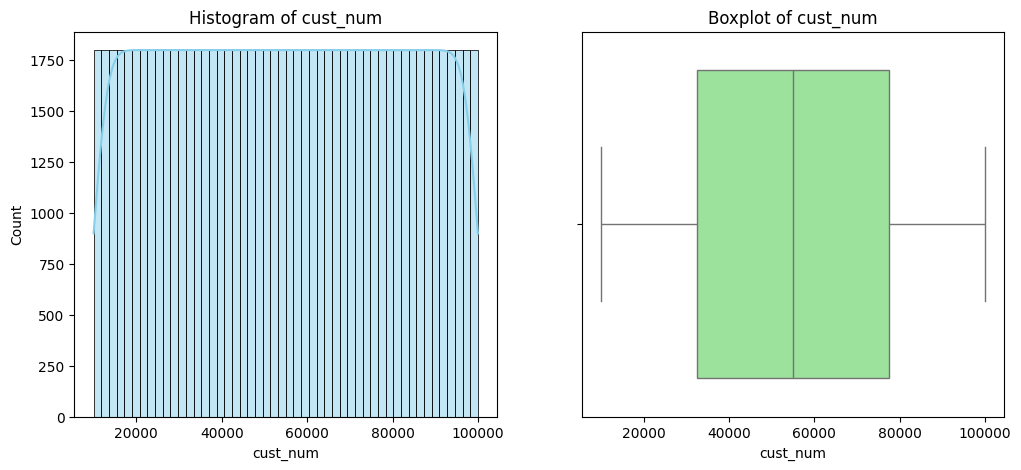

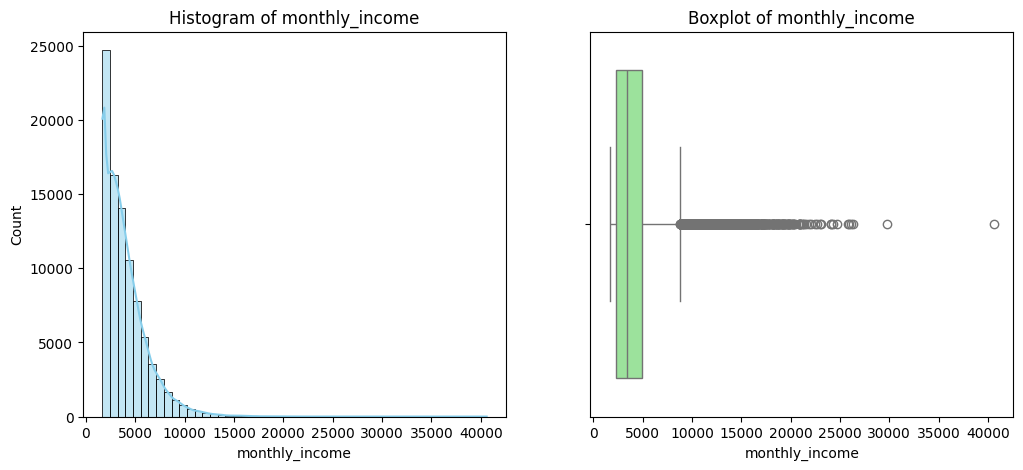

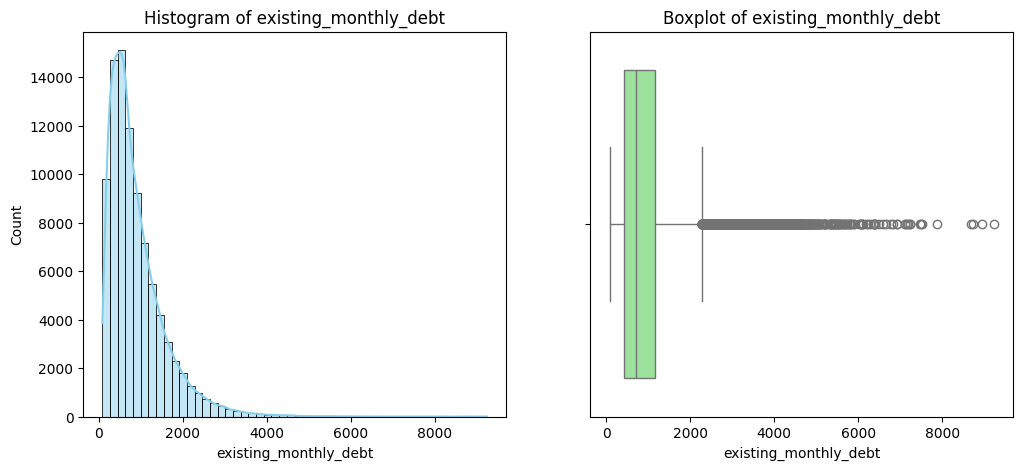

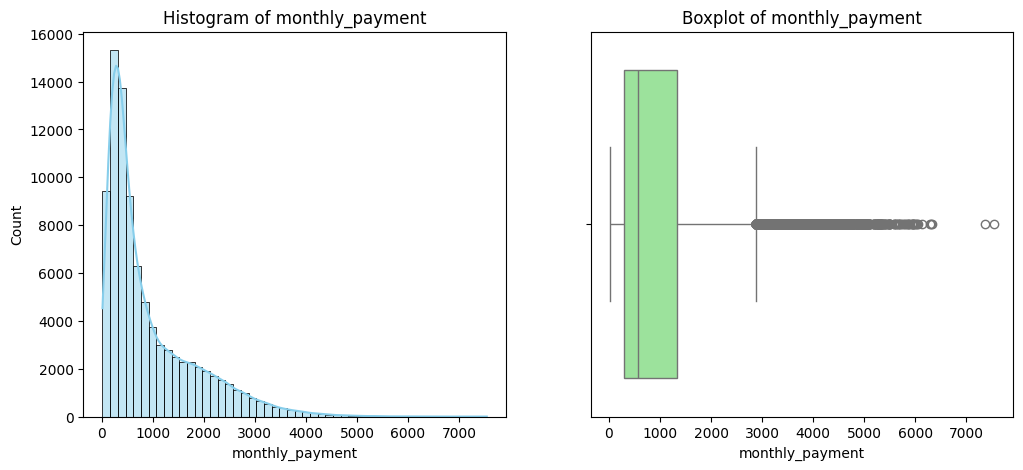

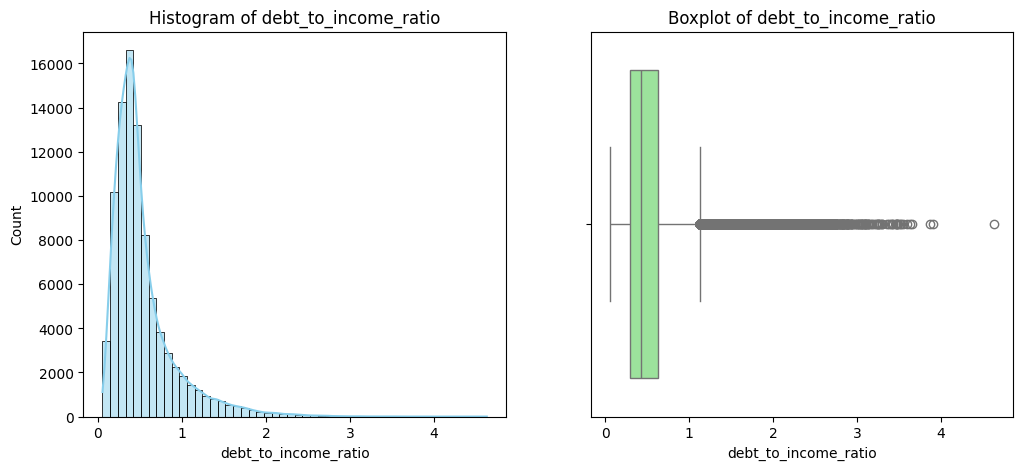

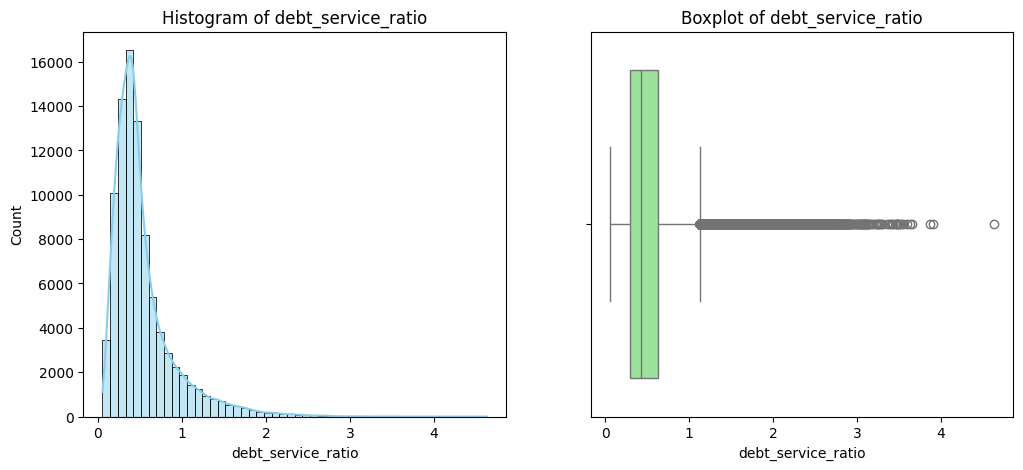

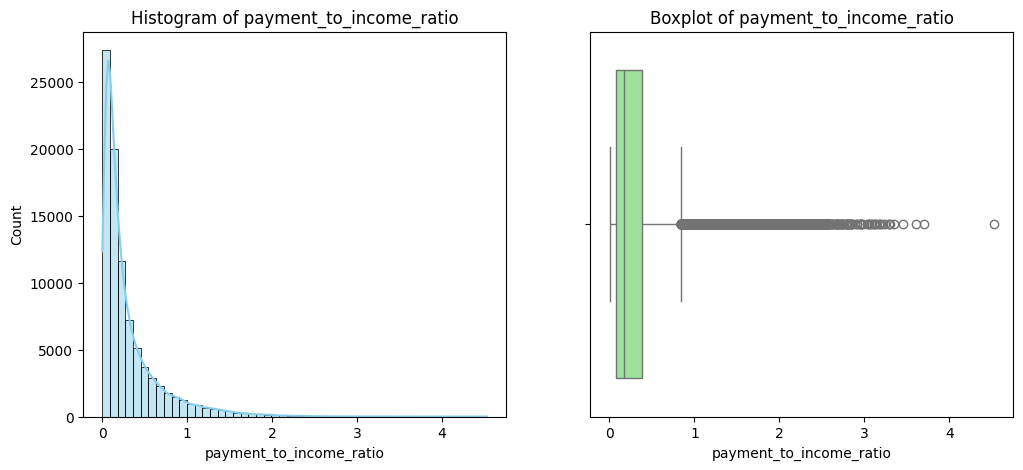

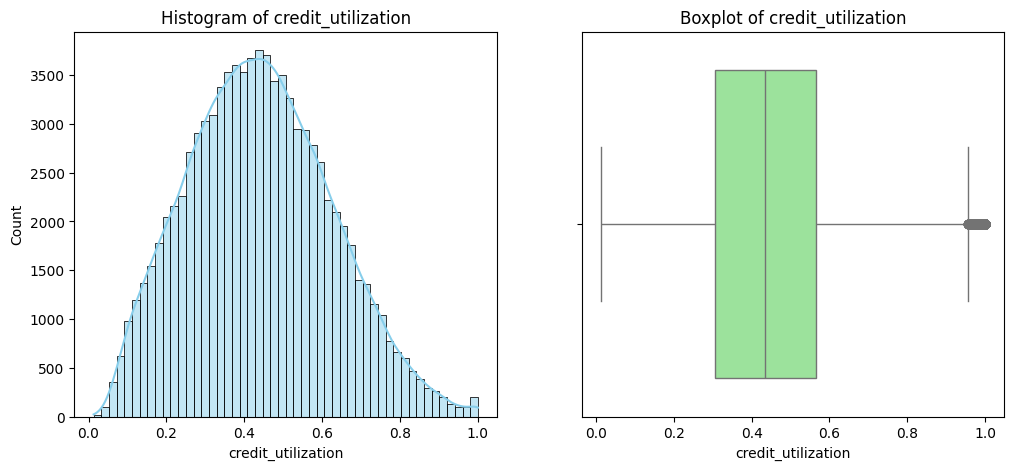

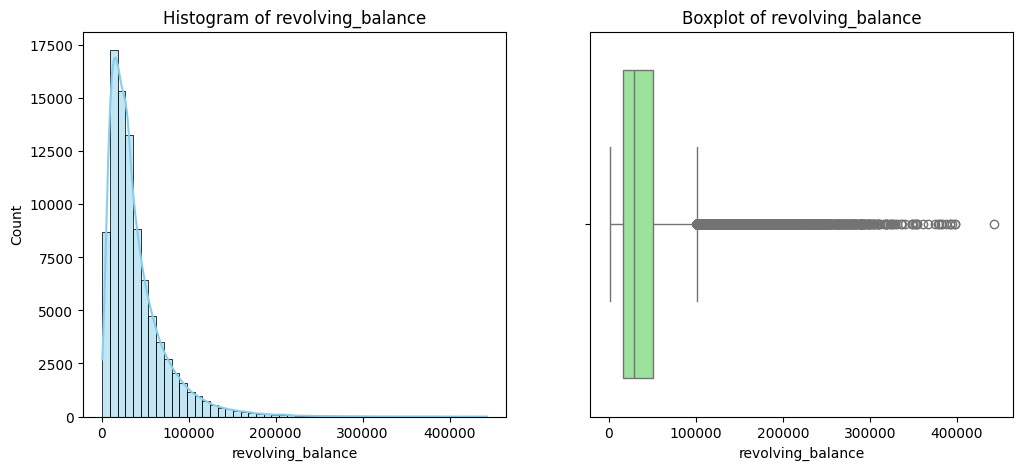

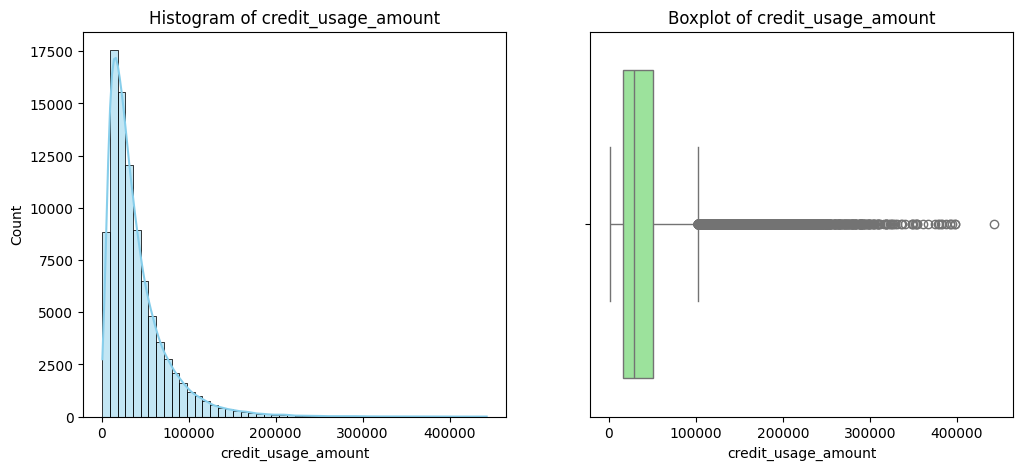

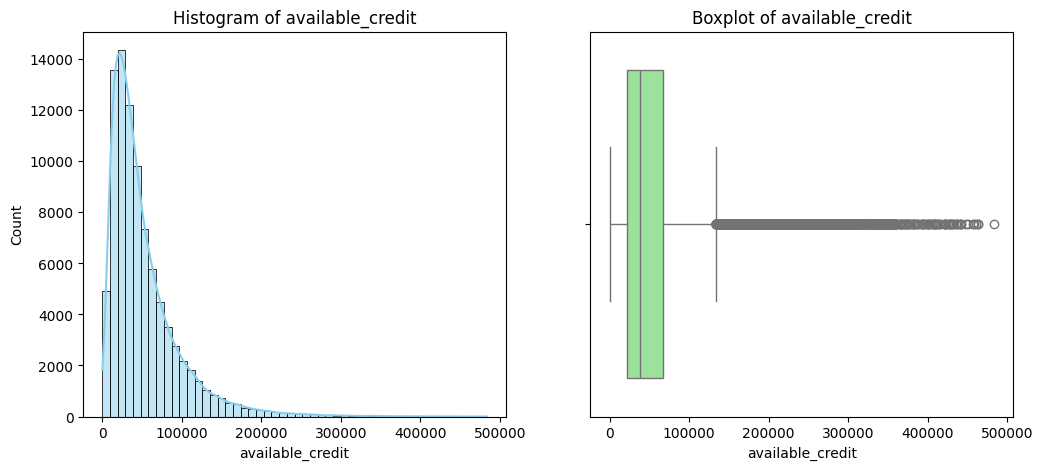

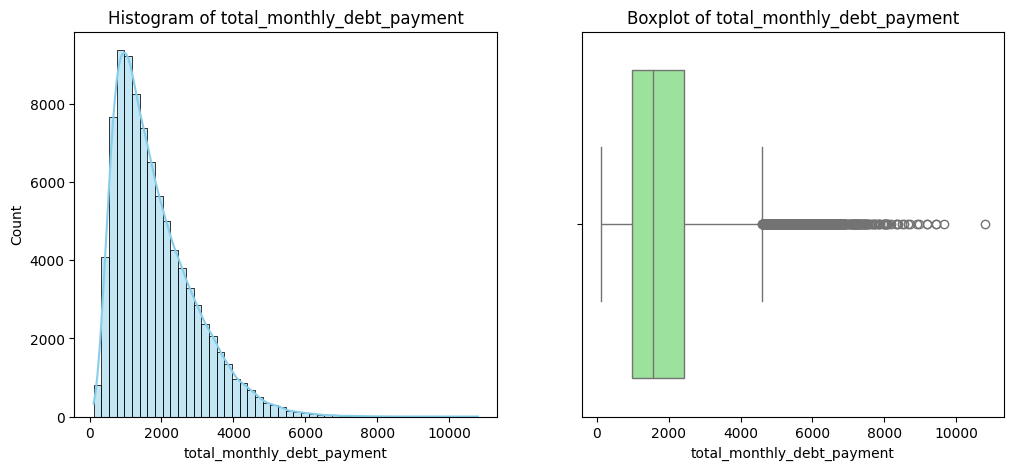

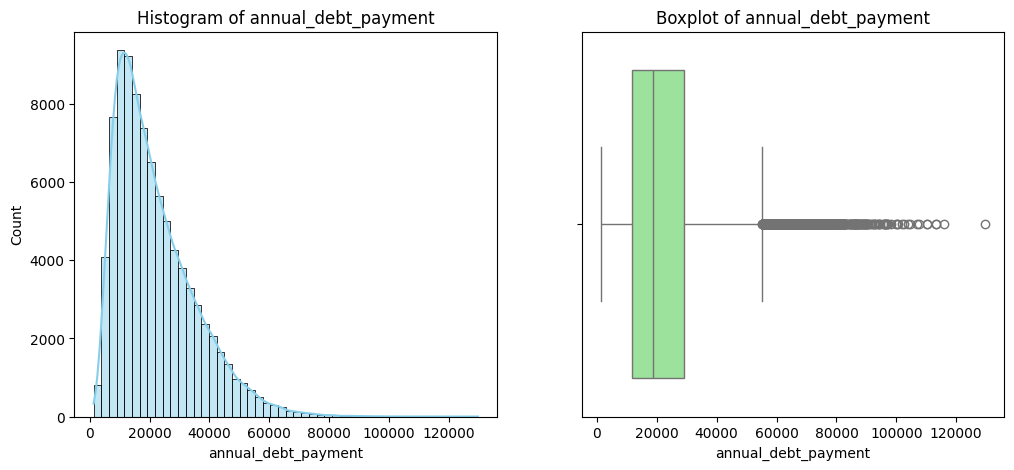

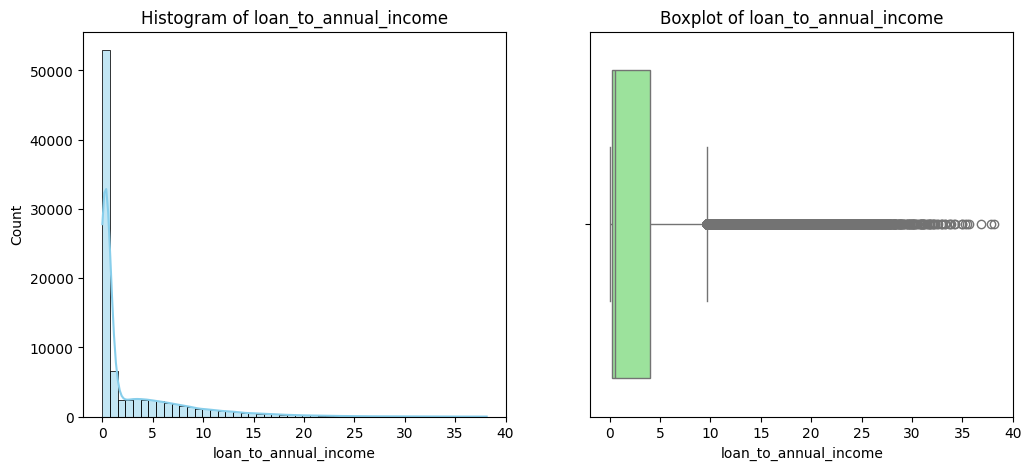

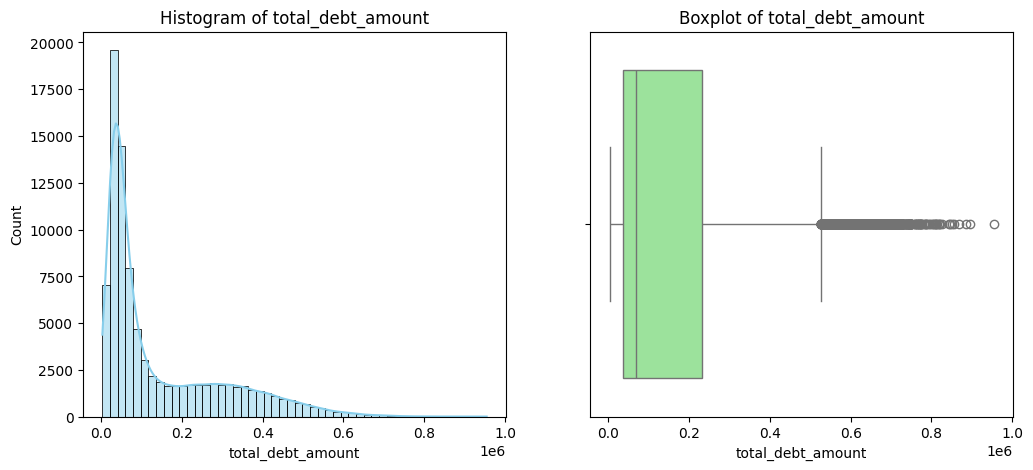

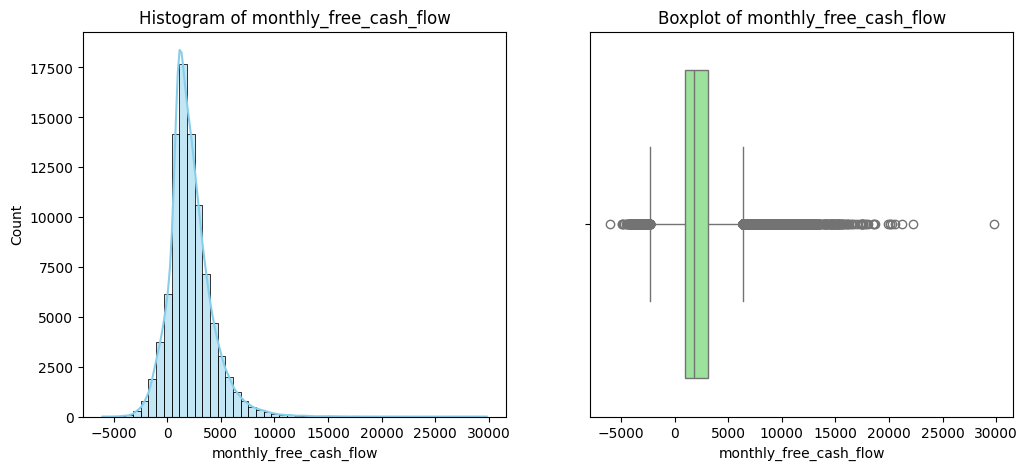

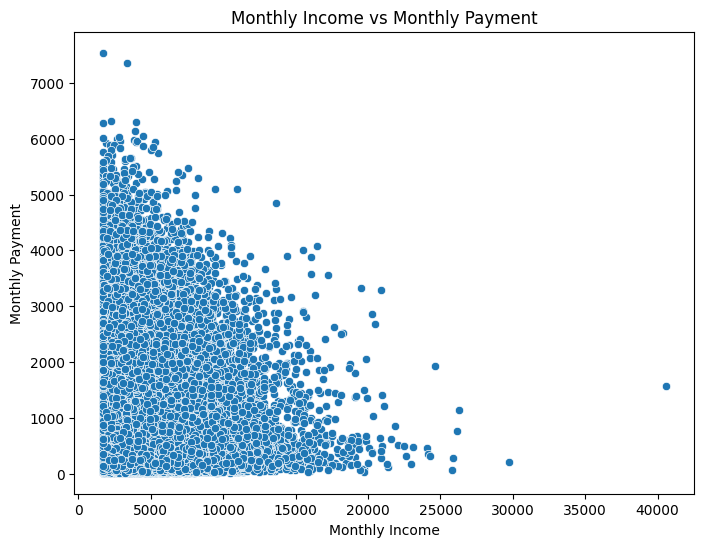

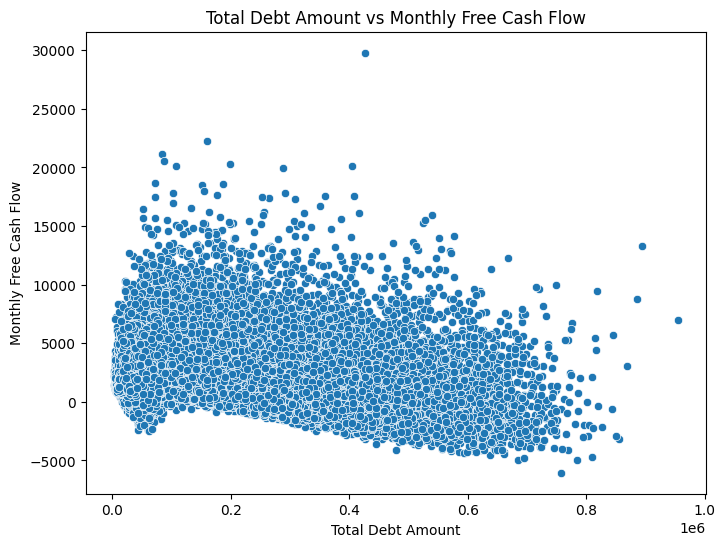

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. JSONL faylni o'qish
# =========================
data = pd.read_json("financial_ratios.jsonl", lines=True)

# =========================
# 2. Dollar va vergul bilan numeric ustunlarni tozalash
# =========================
cols_to_clean = [
    "monthly_income", "existing_monthly_debt", "monthly_payment",
    "revolving_balance", "credit_usage_amount", "available_credit",
    "total_monthly_debt_payment", "annual_debt_payment",
    "total_debt_amount", "monthly_free_cash_flow"
]

for col in cols_to_clean:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)
            .str.replace("$","", regex=False)
            .str.replace(",","", regex=False)
        )
        data[col] = pd.to_numeric(data[col], errors='coerce')

# =========================
# 3. Numeric va kategorik ustunlar
# =========================
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

# =========================
# 4. Bo'sh qiymatlarni to'ldirish (FutureWarning chiqarmaslik uchun)
# =========================
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")

# =========================
# 5. MAD (Modified Z-score) bilan outlier aniqlash funksiyasi
# =========================
def mad_based_outlier(series, threshold=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return [], median, mad
    modified_z_scores = 0.6745 * (series - median) / mad
    outliers = series[np.abs(modified_z_scores) > threshold]
    return outliers, median, mad

# =========================
# 6. Numeric ustunlar uchun outlier tahlili
# =========================
print("=== Numeric columns outlier analysis ===\n")
for col in numeric_cols:
    outliers, median, mad = mad_based_outlier(data[col])
    print(f"Column: {col}")
    print(f" - Median: {median}, MAD: {mad}")
    print(f" - Outliers count: {len(outliers)}")
    if len(outliers) > 0:
        print(f" - Outlier values (sample up to 10): {outliers.values[:10]}\n")
    else:
        print(f" - No outliers detected.\n")

# =========================
# 7. Kategorik ustunlar rare value tahlili
# =========================
print("=== Categorical columns rare value analysis ===\n")
for col in categorical_cols:
    counts = data[col].value_counts()
    rare_values = counts[counts < 0.01 * len(data)]  # 1% threshold
    print(f"Column: {col}")
    if len(rare_values) > 0:
        print(f" - Rare values (less than 1% of data):\n{rare_values}\n")
    else:
        print(" - No rare values detected.\n")

# =========================
# 8. Vizualizatsiya: Histogram va Boxplot
# =========================
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(data[col], bins=50, kde=True, color="skyblue")
    plt.title(f"Histogram of {col}")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
    
    plt.show()

# =========================
# 9. Scatter plot muayyan numeric ustunlar o'rtasida
# =========================
if "monthly_income" in numeric_cols and "monthly_payment" in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data["monthly_income"], y=data["monthly_payment"])
    plt.title("Monthly Income vs Monthly Payment")
    plt.xlabel("Monthly Income")
    plt.ylabel("Monthly Payment")
    plt.show()

if "total_debt_amount" in numeric_cols and "monthly_free_cash_flow" in numeric_cols:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data["total_debt_amount"], y=data["monthly_free_cash_flow"])
    plt.title("Total Debt Amount vs Monthly Free Cash Flow")
    plt.xlabel("Total Debt Amount")
    plt.ylabel("Monthly Free Cash Flow")
    plt.show()


In [8]:
import pandas as pd
import numpy as np

# =========================
# 1. JSONL faylni o'qish
# =========================
data = pd.read_json("financial_ratios.jsonl", lines=True)

# =========================
# 2. Dollar va vergul bilan numeric ustunlarni tozalash
# =========================
cols_to_clean = [
    "monthly_income", "existing_monthly_debt", "monthly_payment",
    "revolving_balance", "credit_usage_amount", "available_credit",
    "total_monthly_debt_payment", "annual_debt_payment",
    "total_debt_amount", "monthly_free_cash_flow"
]

for col in cols_to_clean:
    if col in data.columns:
        data[col] = (
            data[col].astype(str)
            .str.replace("$","", regex=False)
            .str.replace(",","", regex=False)
        )
        data[col] = pd.to_numeric(data[col], errors='coerce')

# =========================
# 3. Bo'sh qiymatlarni to'ldirish
# =========================
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

for col in categorical_cols:
    data[col] = data[col].fillna("Unknown")

# =========================
# 4. Duplicate qatordan xalos bo'lish
# =========================
data.drop_duplicates(inplace=True)

# =========================
# 5. Natijani yangi CSV faylga saqlash
# =========================
data.to_csv("financial_ratios_cleaned.csv", index=False)

print("Data tozalandi va 'financial_ratios_cleaned.csv' nomli faylga saqlandi.")


Data tozalandi va 'financial_ratios_cleaned.csv' nomli faylga saqlandi.


In [9]:
data = pd.read_csv("financial_ratios_cleaned.csv")
data.head()

,cust_num,monthly_income,existing_monthly_debt,monthly_payment,debt_to_income_ratio,debt_service_ratio,payment_to_income_ratio,credit_utilization,revolving_balance,credit_usage_amount,available_credit,total_monthly_debt_payment,annual_debt_payment,loan_to_annual_income,total_debt_amount,monthly_free_cash_flow
0,10000,5150.00,738.64,592.13,0.258,0.258402,0.115,0.841,142213.1,142213.1,26886.9,1330.77,15969.24,0.286408,159913.1,3819.230000
1,10001,2383.33,392.21,1013.86,0.590,0.589959,0.425,0.971,75932.2,75932.2,2267.8,1406.07,16872.84,3.986014,189932.2,977.260000
2,10002,1725.00,204.07,317.81,0.303,0.302539,0.184,0.539,22314.6,22314.6,19085.4,521.88,6262.56,0.449275,31614.6,1203.120000
3,10003,2616.67,288.71,234.52,0.200,0.199961,0.090,0.147,8820.0,8820.0,51180.0,523.23,6278.76,0.277070,17520.0,2093.436667
4,10004,2050.00,248.77,334.81,0.285,0.284673,0.163,0.488,24253.6,24253.6,25446.4,583.58,7002.96,0.292683,31453.6,1466.420000


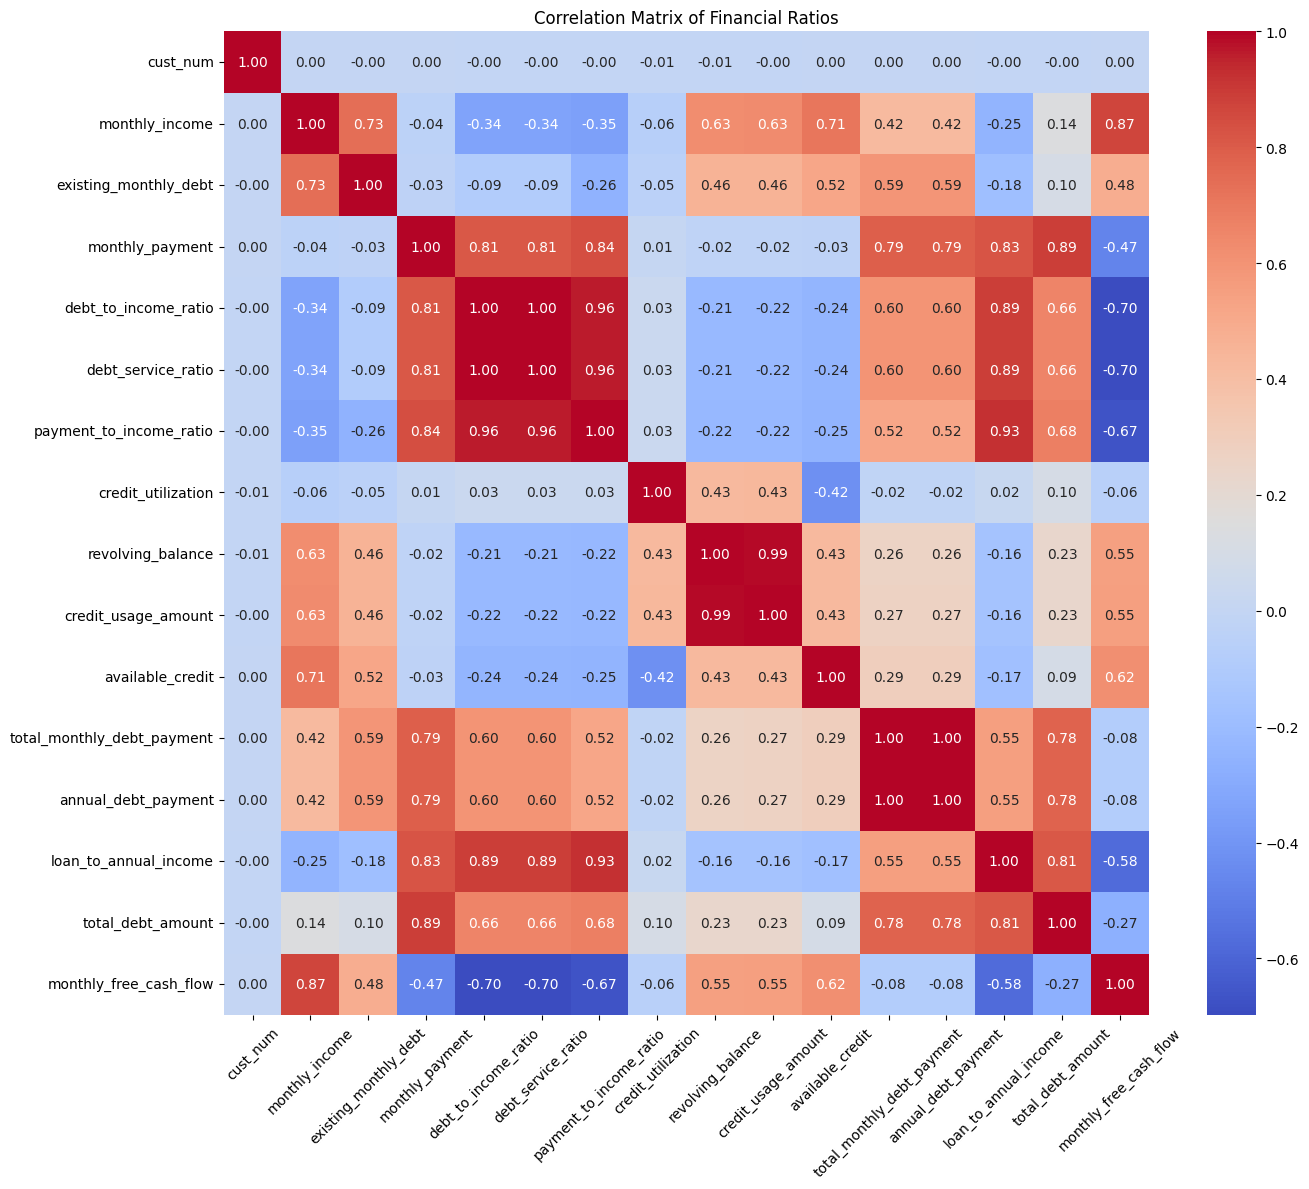

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Tozalangan CSV faylni o'qish
# =========================
data = pd.read_csv("financial_ratios_cleaned.csv")

# =========================
# 2. Correlation matritsasini hisoblash
# =========================
numeric_cols = [
    "cust_num", "monthly_income", "existing_monthly_debt", "monthly_payment",
    "debt_to_income_ratio", "debt_service_ratio", "payment_to_income_ratio",
    "credit_utilization", "revolving_balance", "credit_usage_amount",
    "available_credit", "total_monthly_debt_payment", "annual_debt_payment",
    "loan_to_annual_income", "total_debt_amount", "monthly_free_cash_flow"
]

corr_matrix = data[numeric_cols].corr()

# Correlation matritsasini CSV faylga saqlash
corr_matrix.to_csv("financial_ratios_correlation.csv")

# =========================
# 3. Heatmap orqali vizualizatsiya
# =========================
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Financial Ratios")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


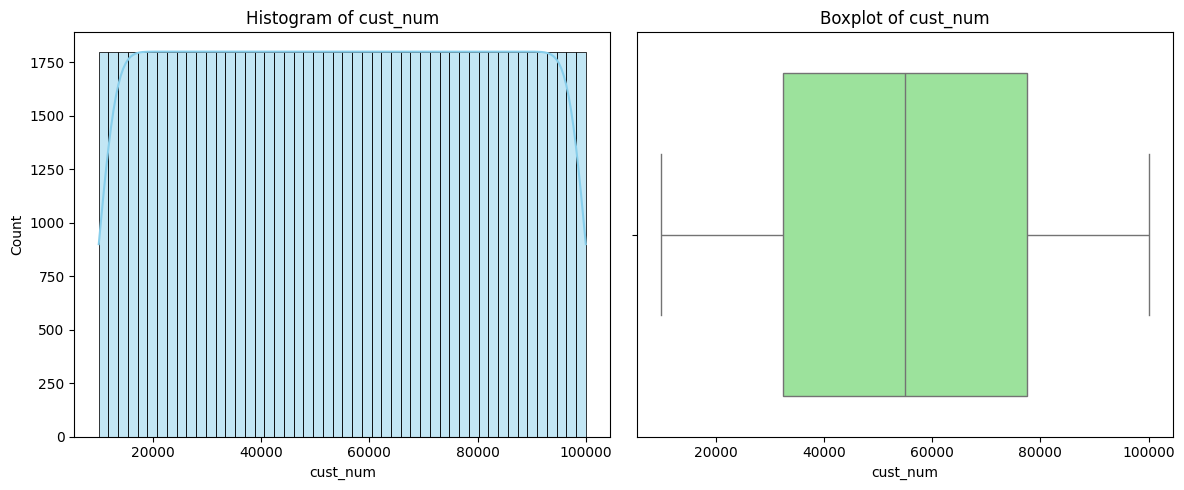

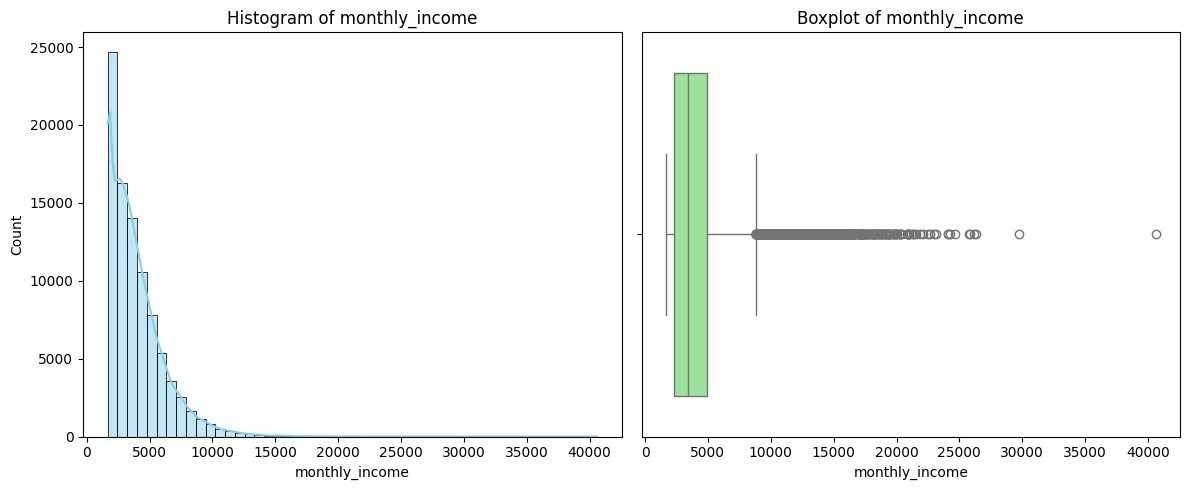

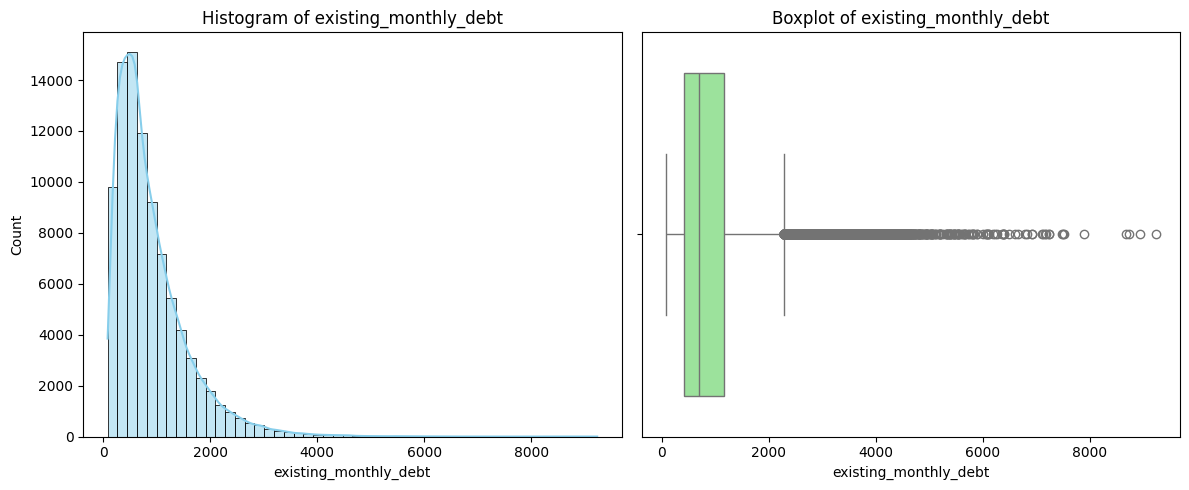

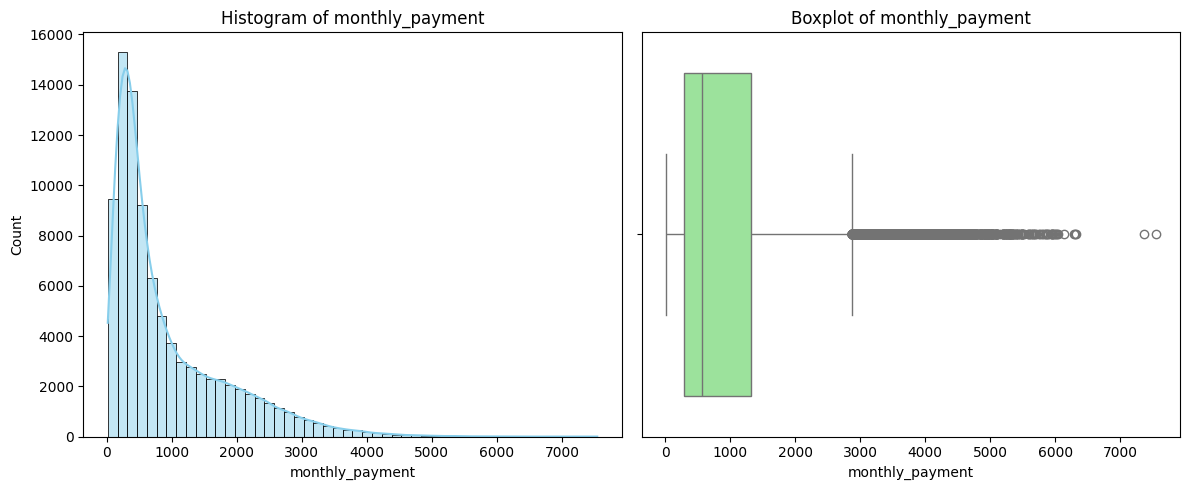

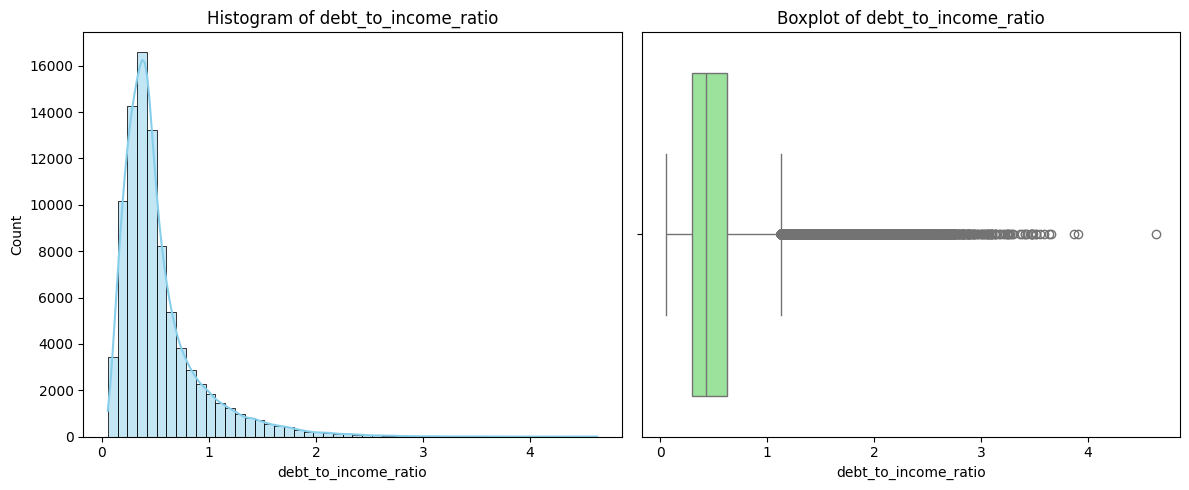

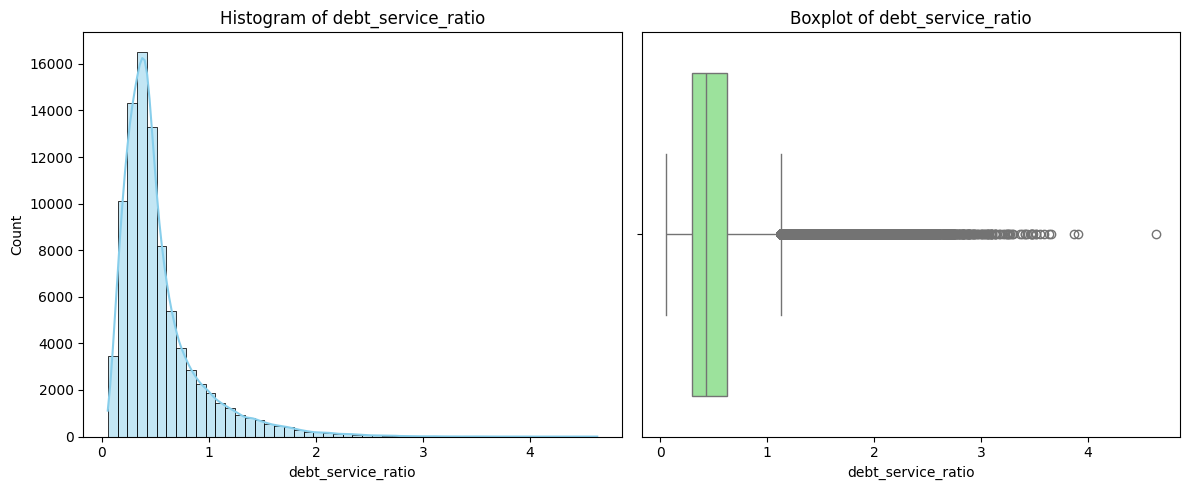

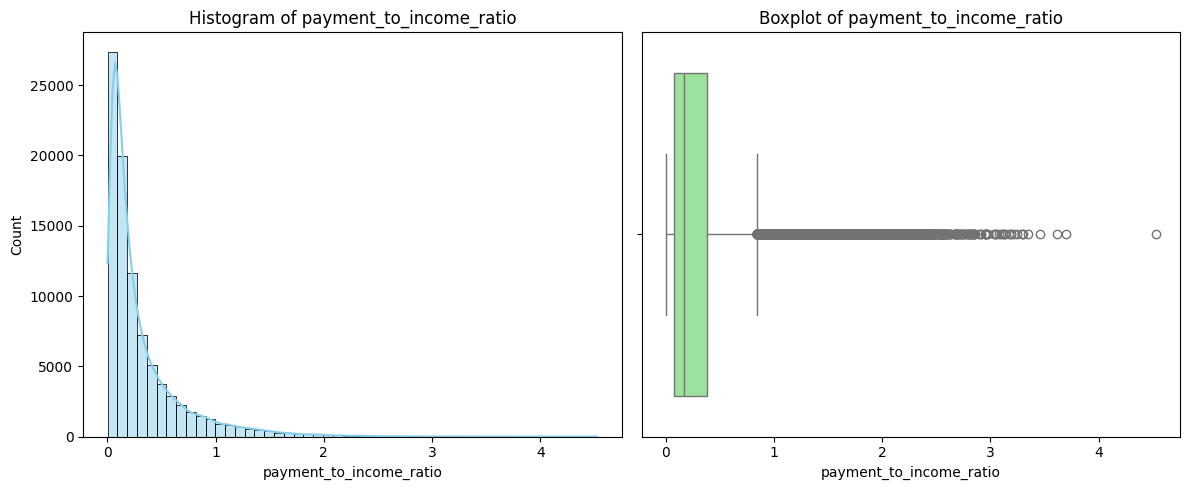

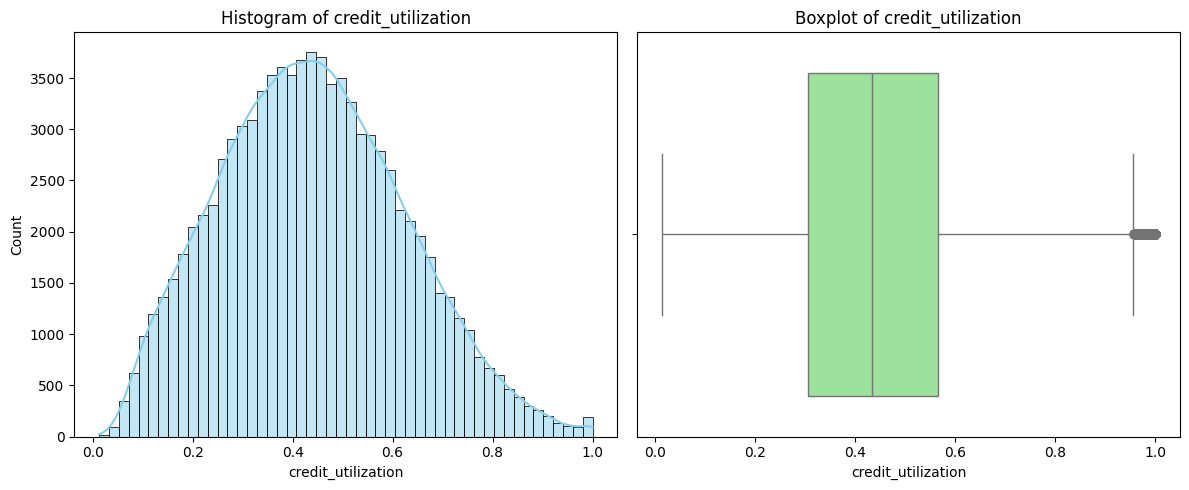

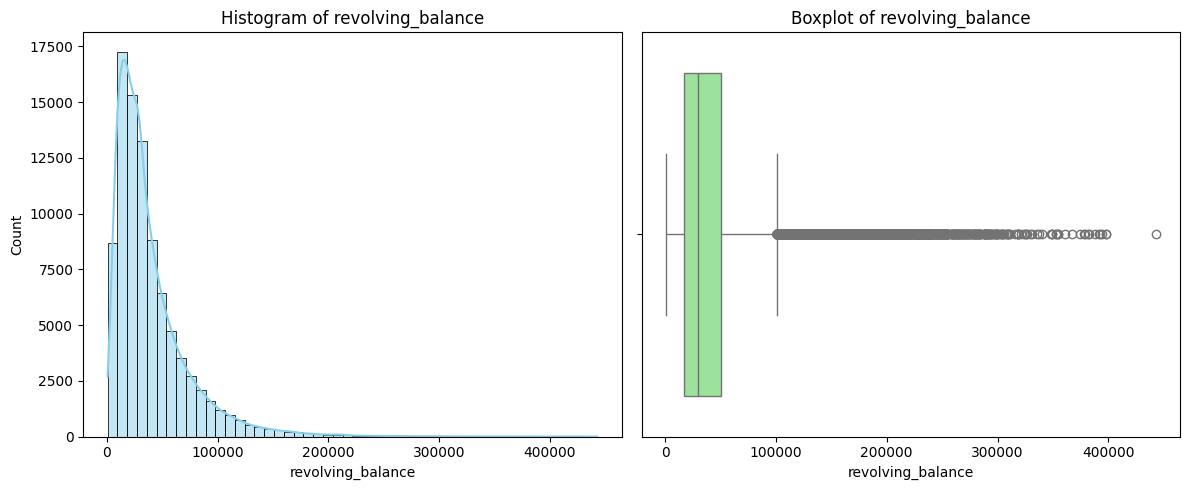

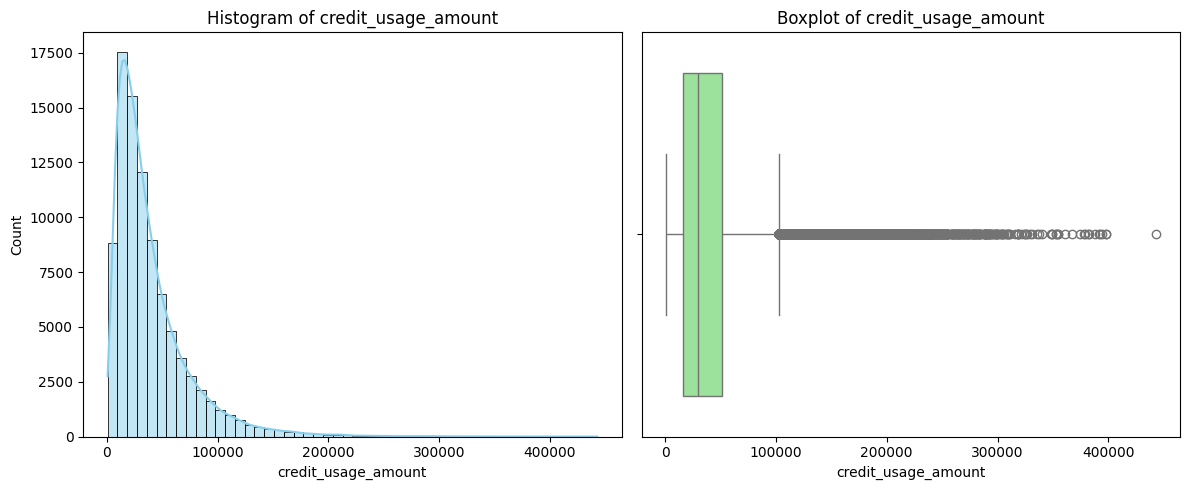

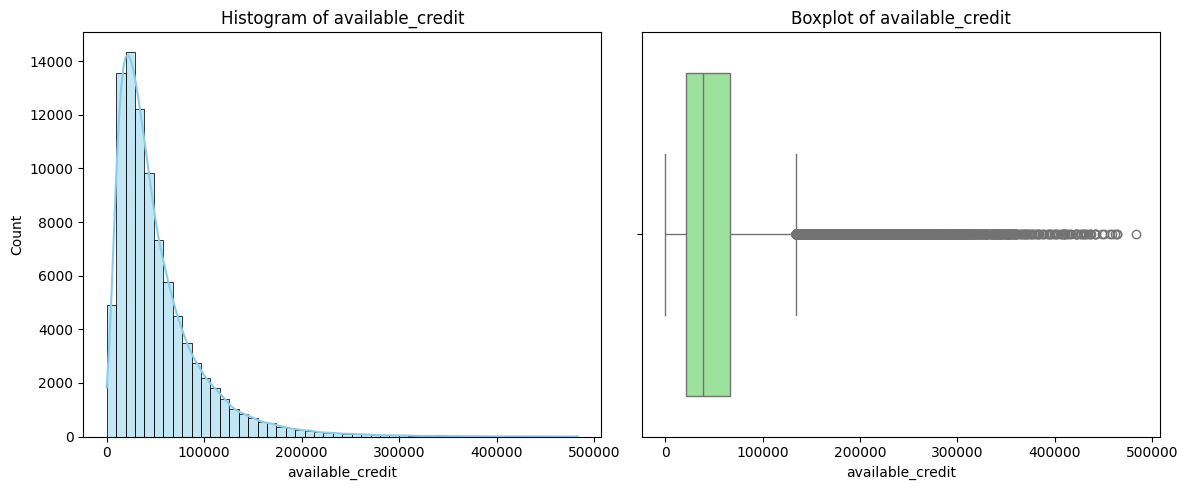

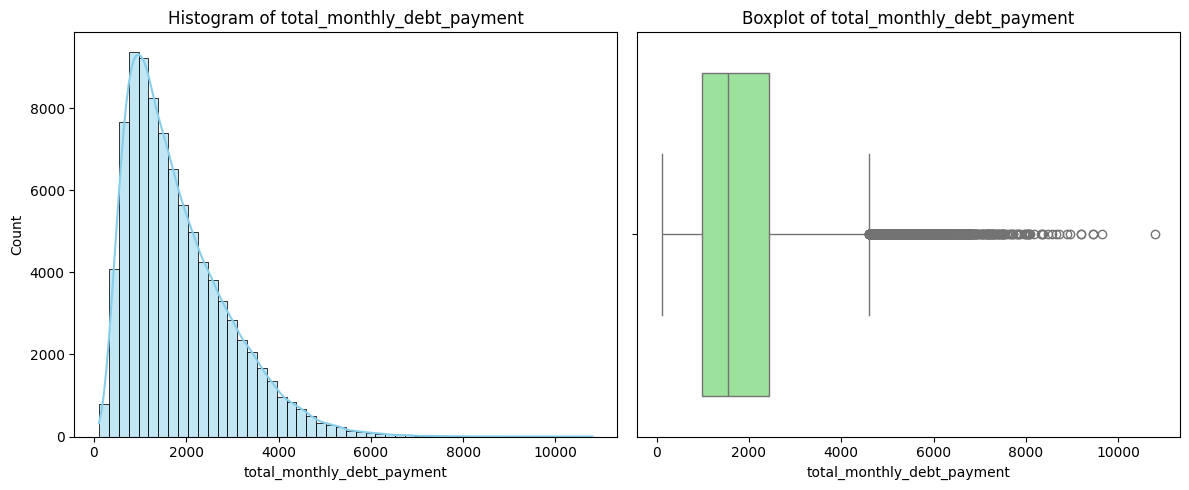

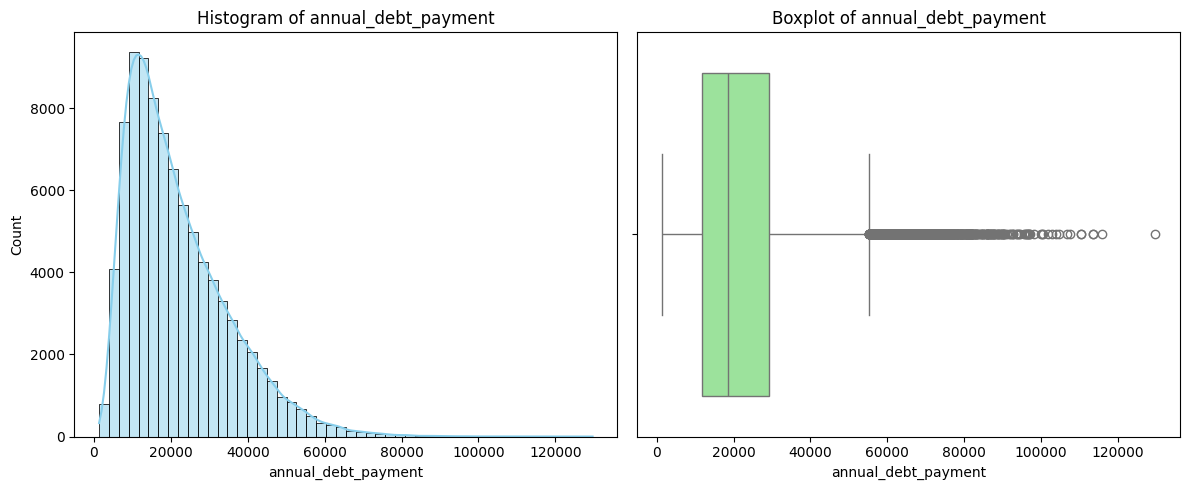

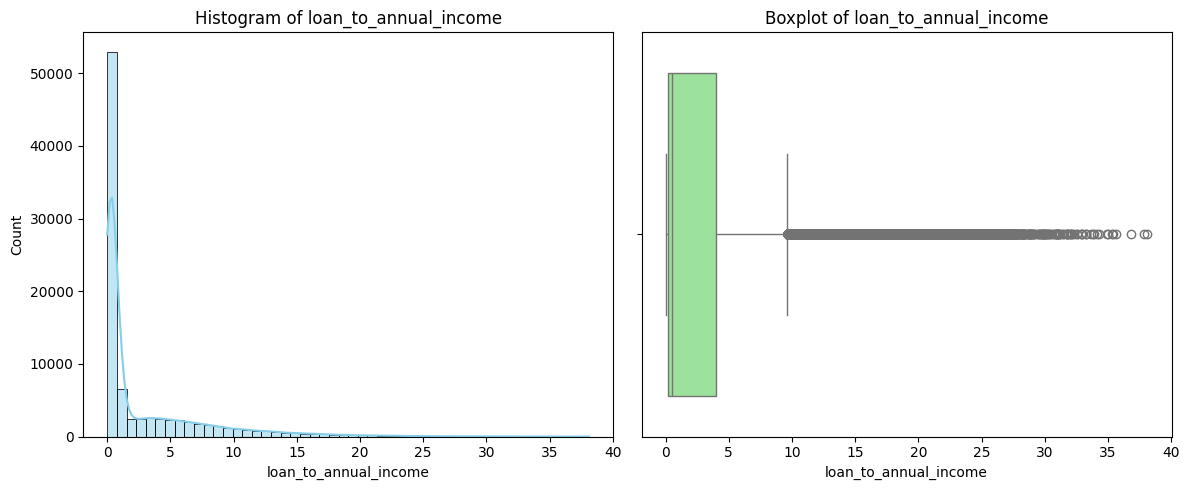

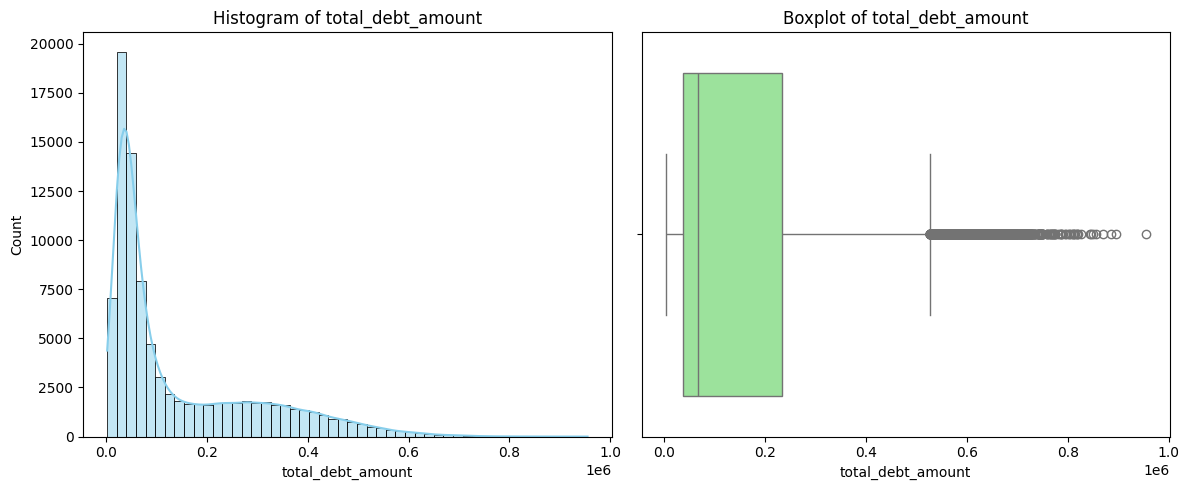

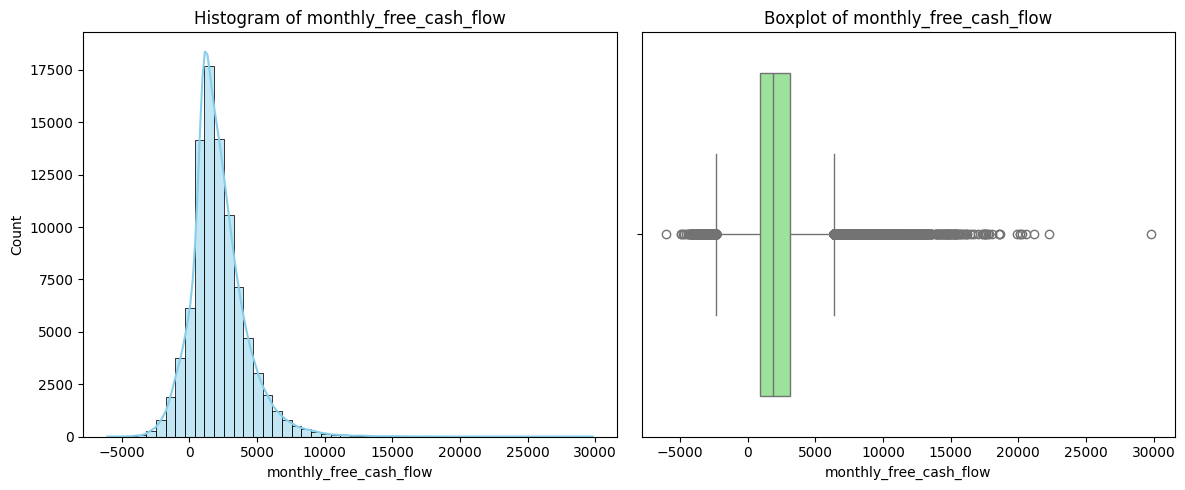

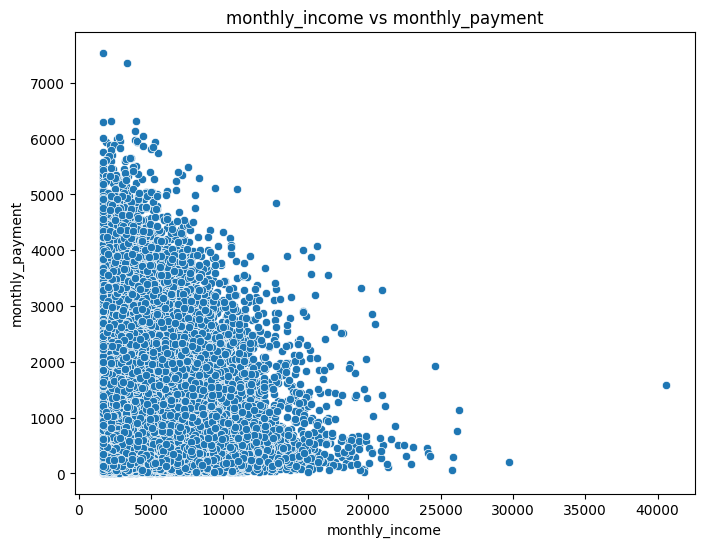

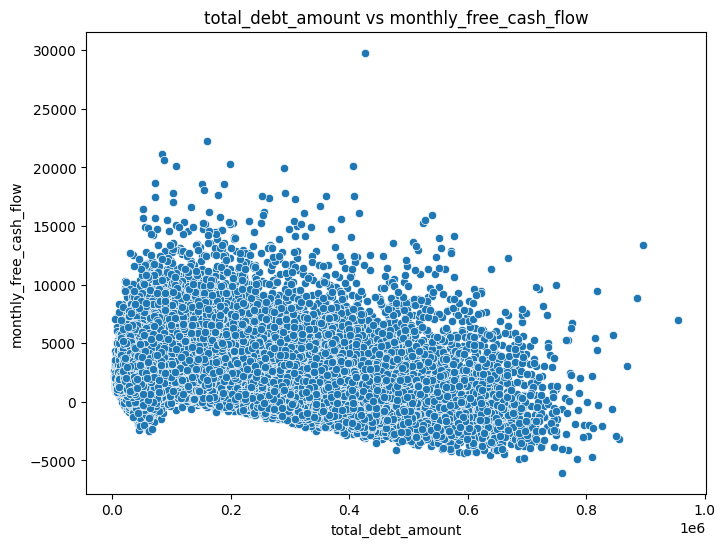

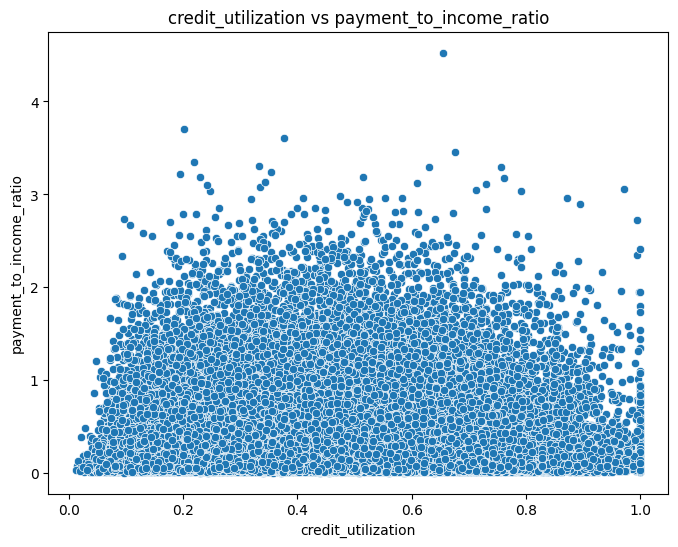

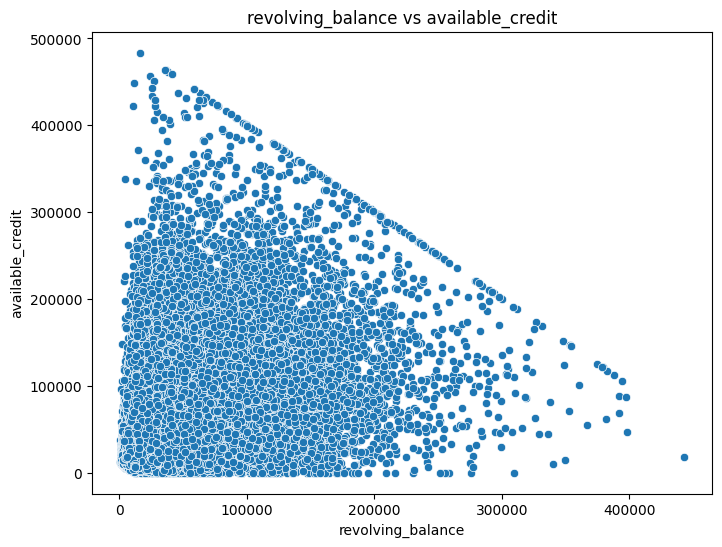

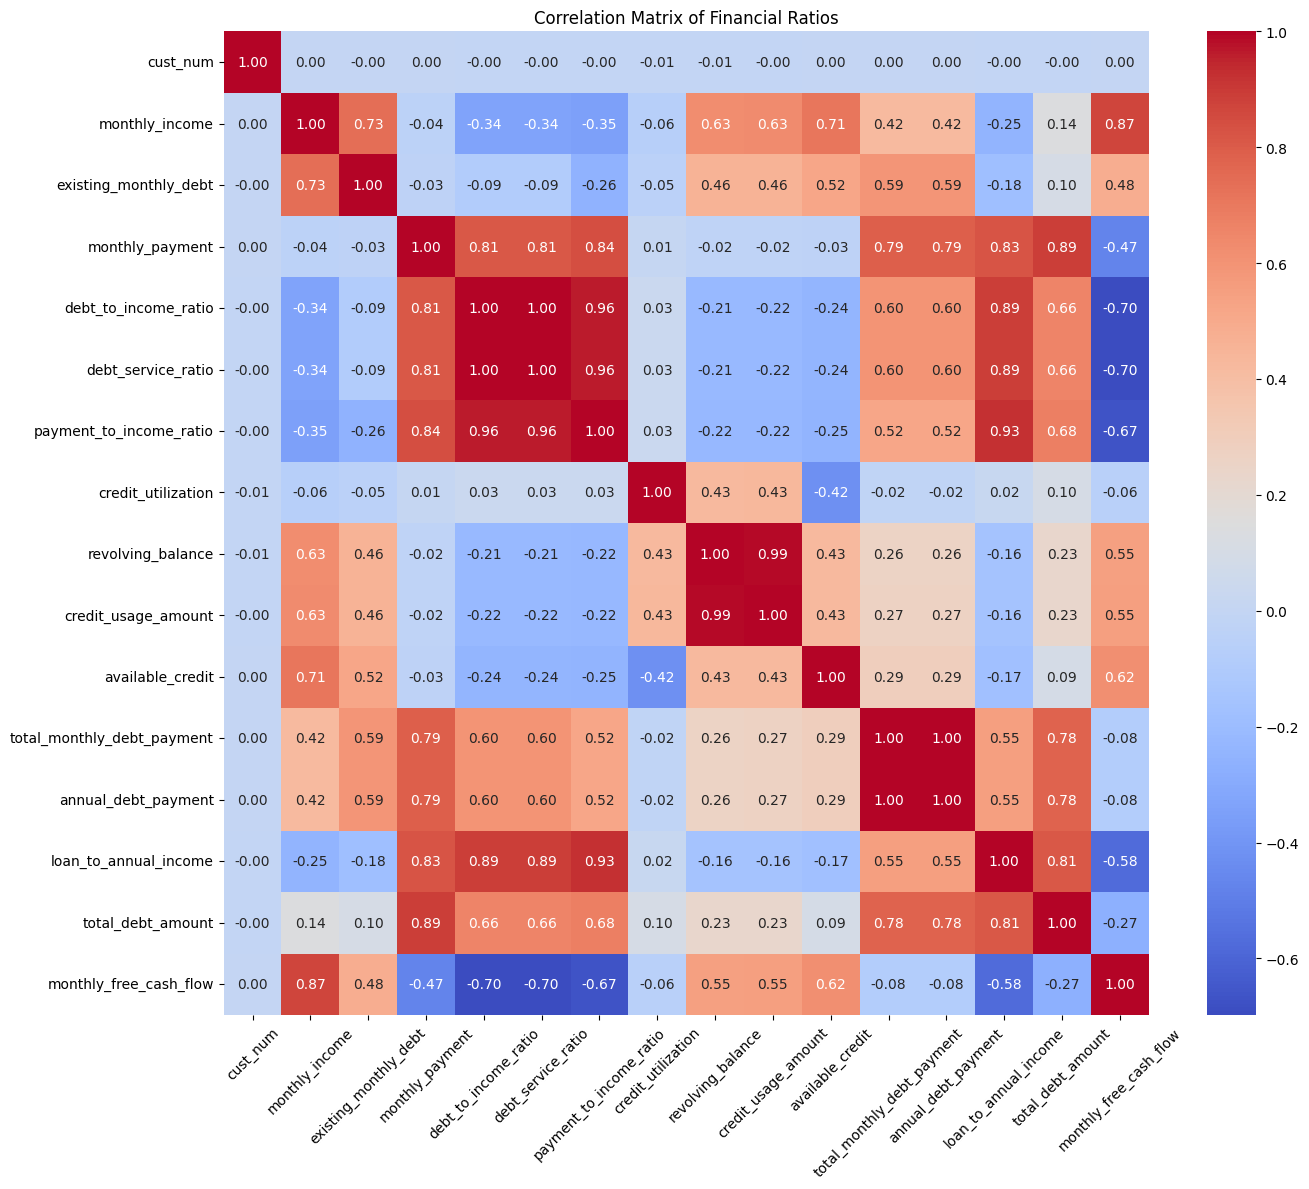

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Tozalangan CSV faylni o'qish
# =========================
data = pd.read_csv("financial_ratios_cleaned.csv")

# =========================
# 2. Numeric ustunlar ro'yxati
# =========================
numeric_cols = [
    "cust_num", "monthly_income", "existing_monthly_debt", "monthly_payment",
    "debt_to_income_ratio", "debt_service_ratio", "payment_to_income_ratio",
    "credit_utilization", "revolving_balance", "credit_usage_amount",
    "available_credit", "total_monthly_debt_payment", "annual_debt_payment",
    "loan_to_annual_income", "total_debt_amount", "monthly_free_cash_flow"
]

# =========================
# 3. Histogram va Boxplot har bir ustun uchun
# =========================
for col in numeric_cols:
    plt.figure(figsize=(12,5))
    
    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(data[col], bins=50, kde=True, color="skyblue")
    plt.title(f"Histogram of {col}")
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col], color="lightgreen")
    plt.title(f"Boxplot of {col}")
    
    plt.tight_layout()
    plt.show()

# =========================
# 4. Scatterplotlar (qiziq numeric ustunlar o'rtasida)
# =========================
scatter_pairs = [
    ("monthly_income", "monthly_payment"),
    ("total_debt_amount", "monthly_free_cash_flow"),
    ("credit_utilization", "payment_to_income_ratio"),
    ("revolving_balance", "available_credit")
]

for x_col, y_col in scatter_pairs:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=data[x_col], y=data[y_col])
    plt.title(f"{x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

# =========================
# 5. Correlation heatmap
# =========================
corr_matrix = data[numeric_cols].corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Financial Ratios")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


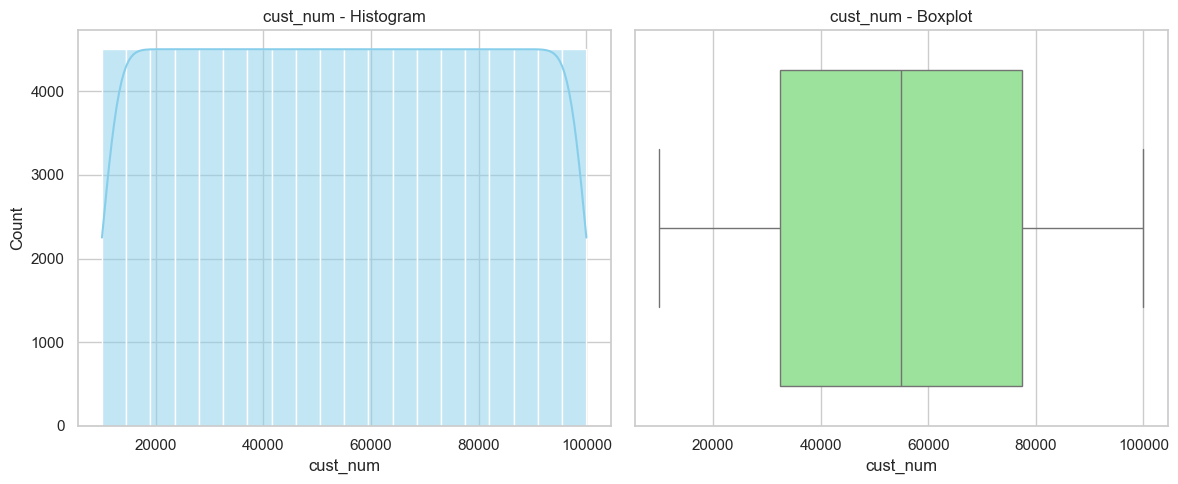

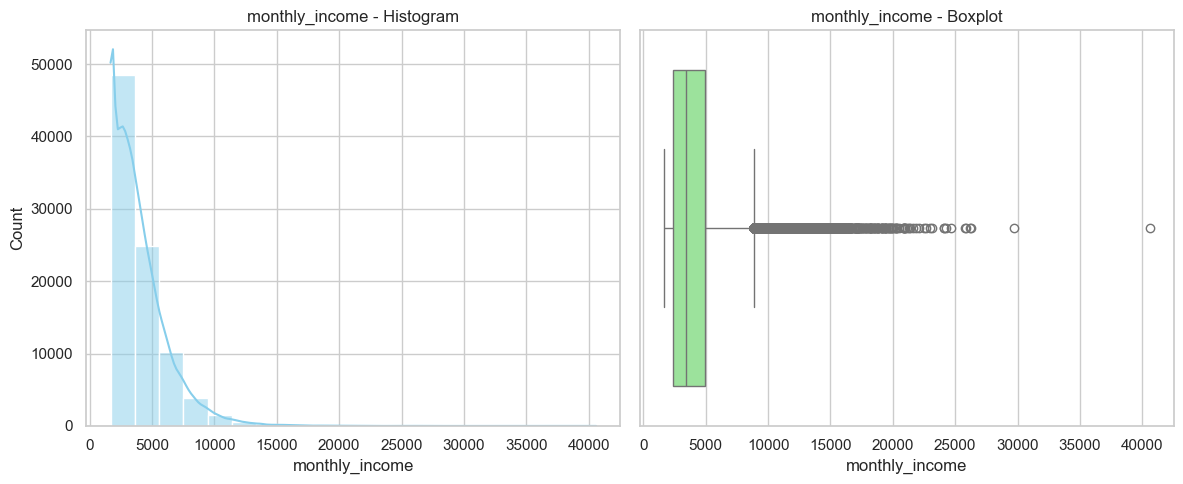

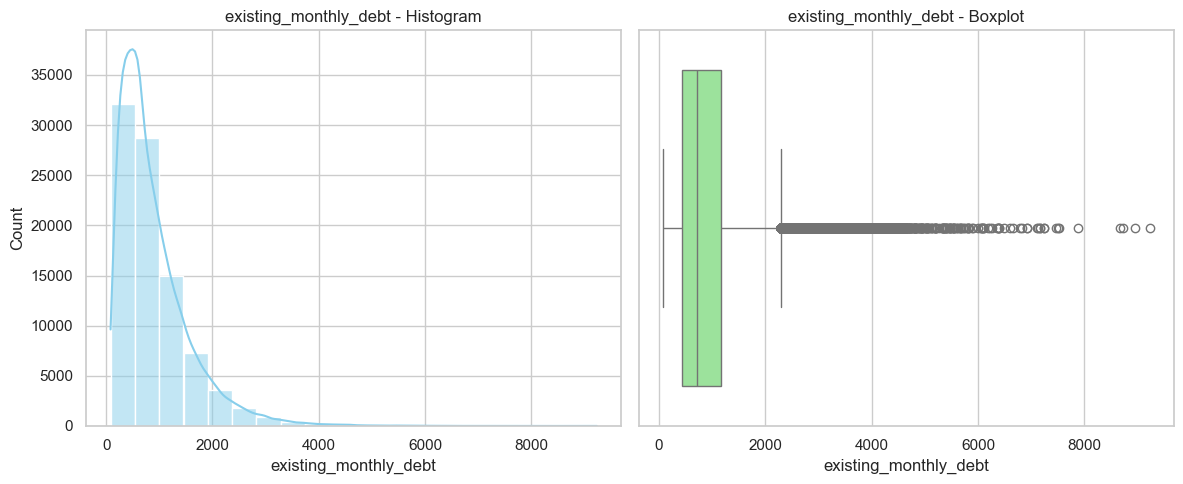

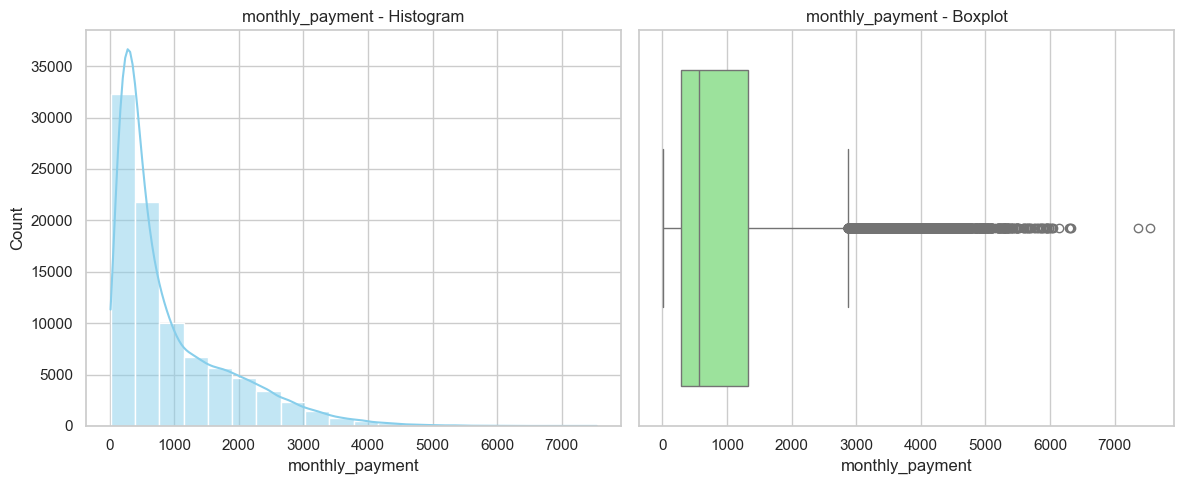

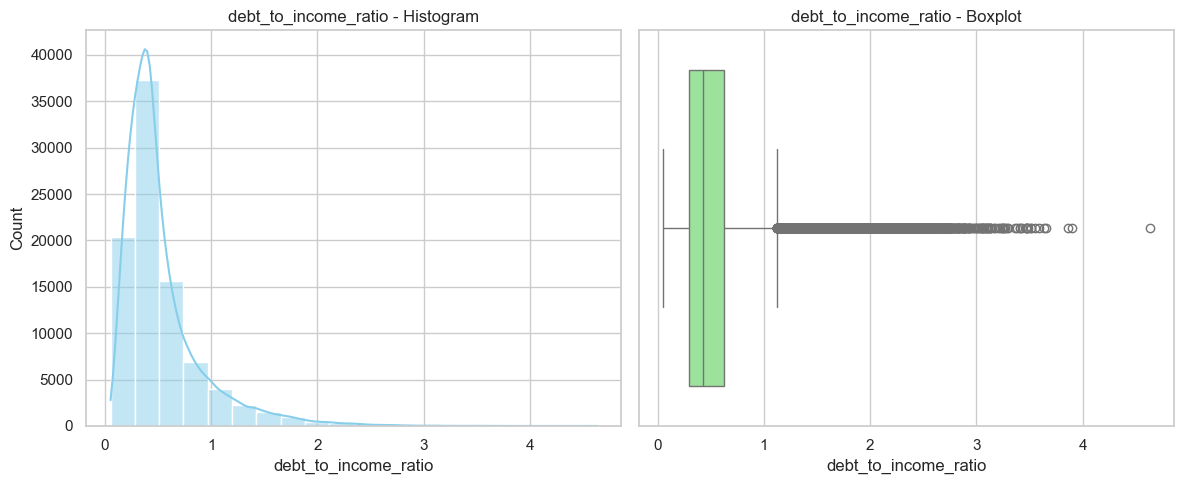

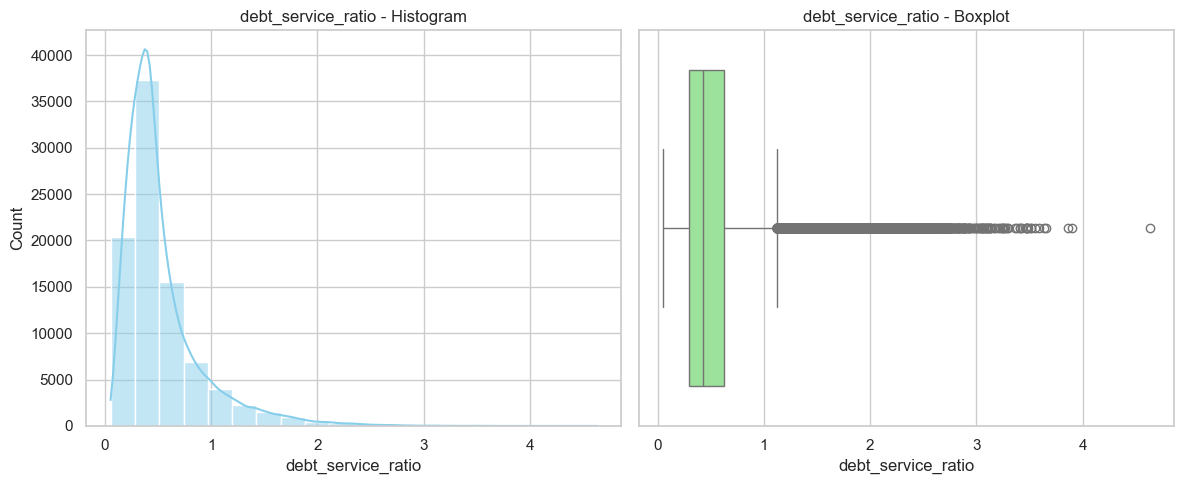

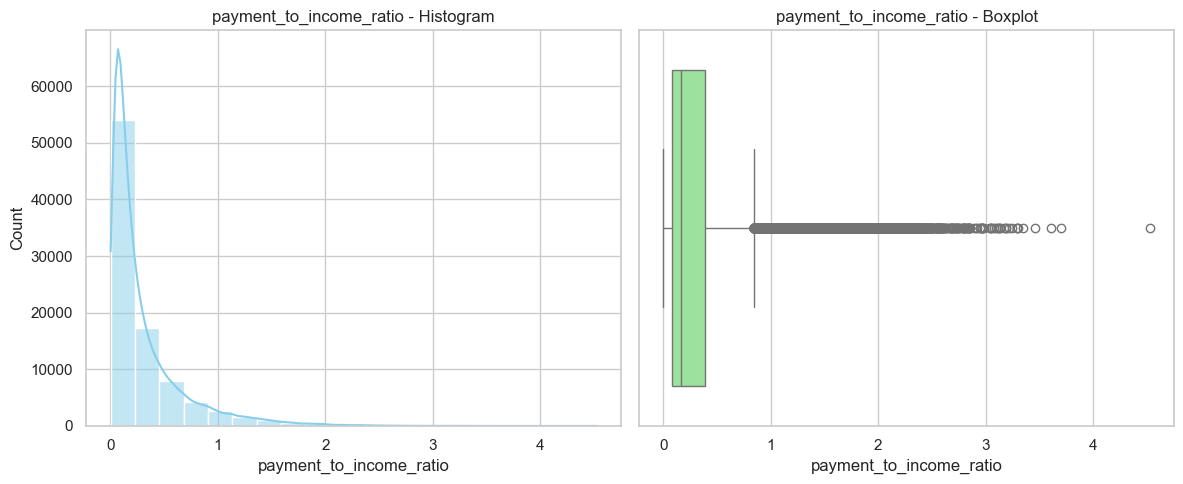

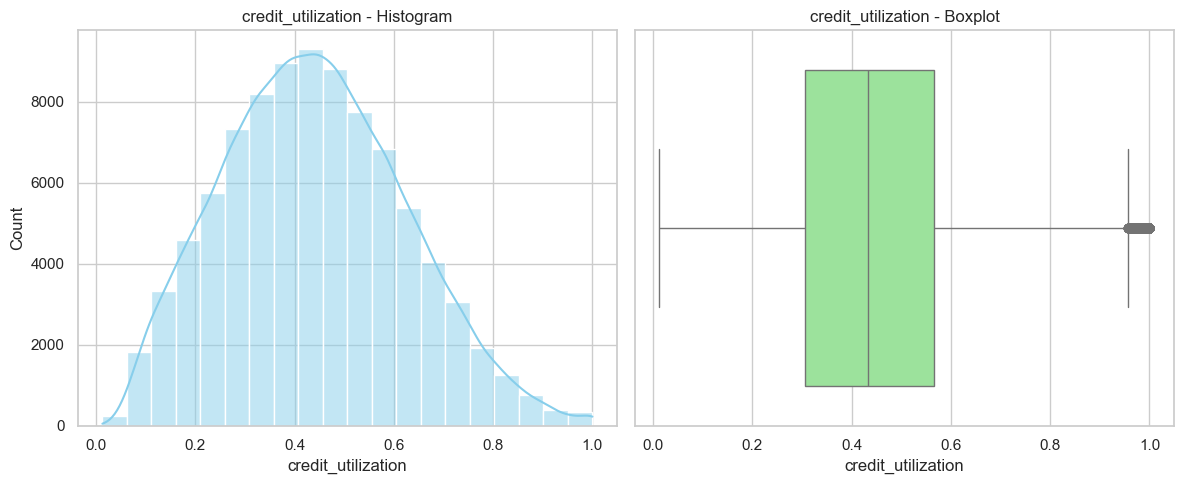

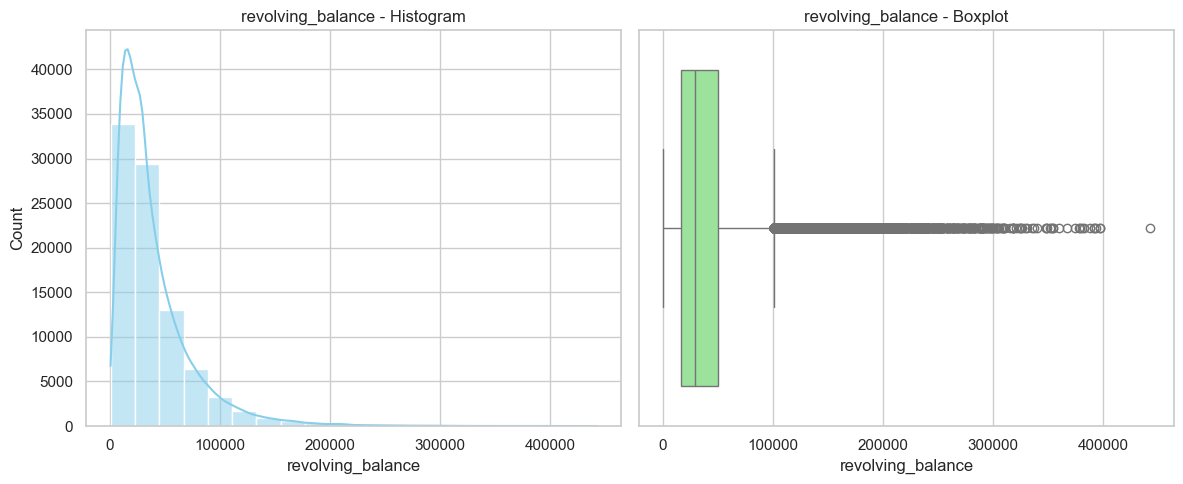

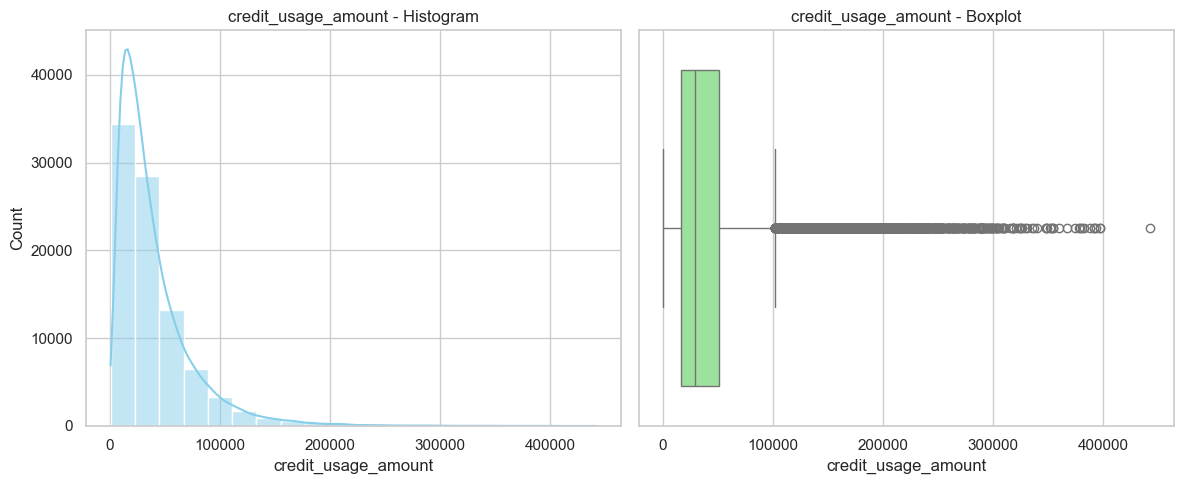

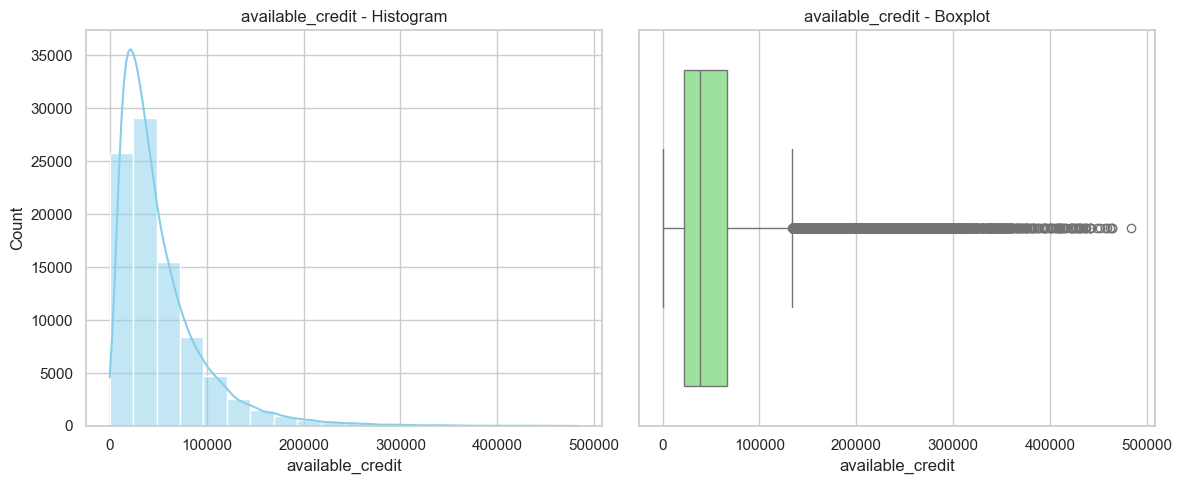

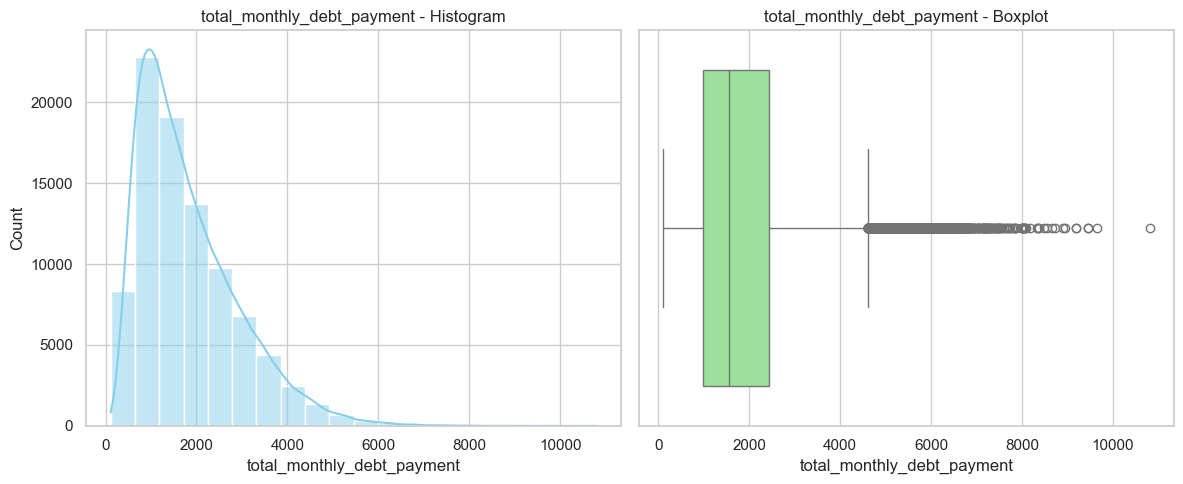

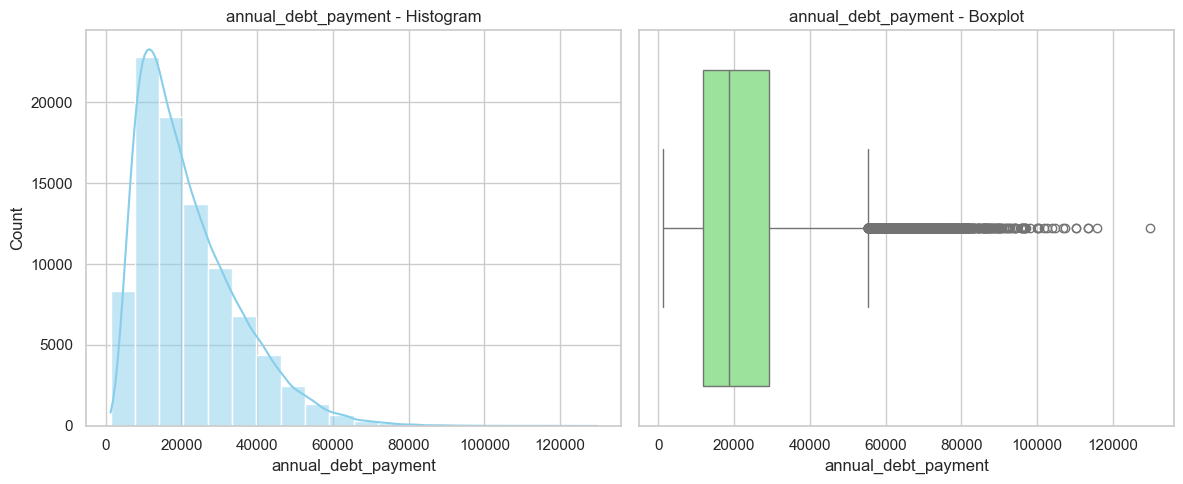

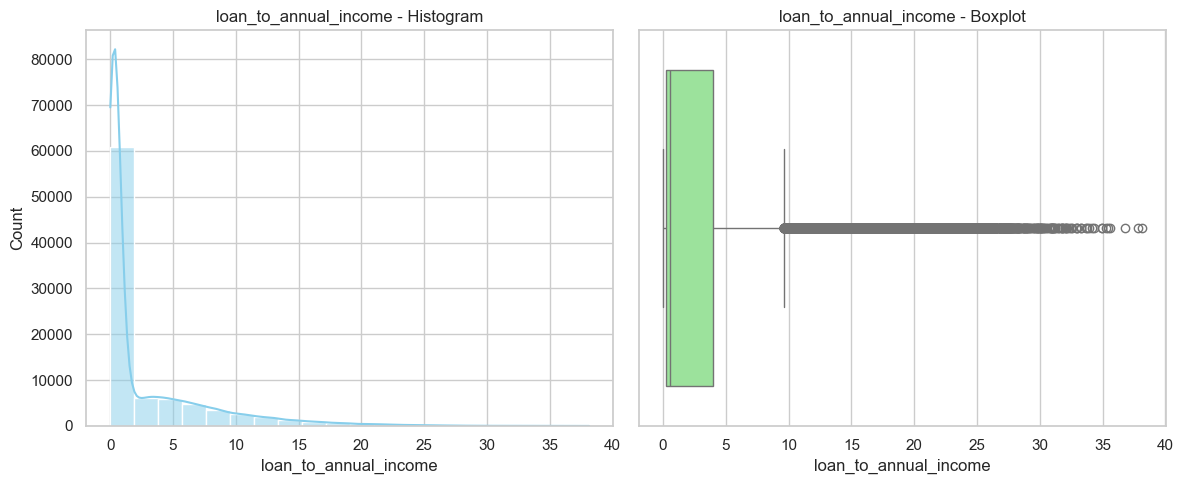

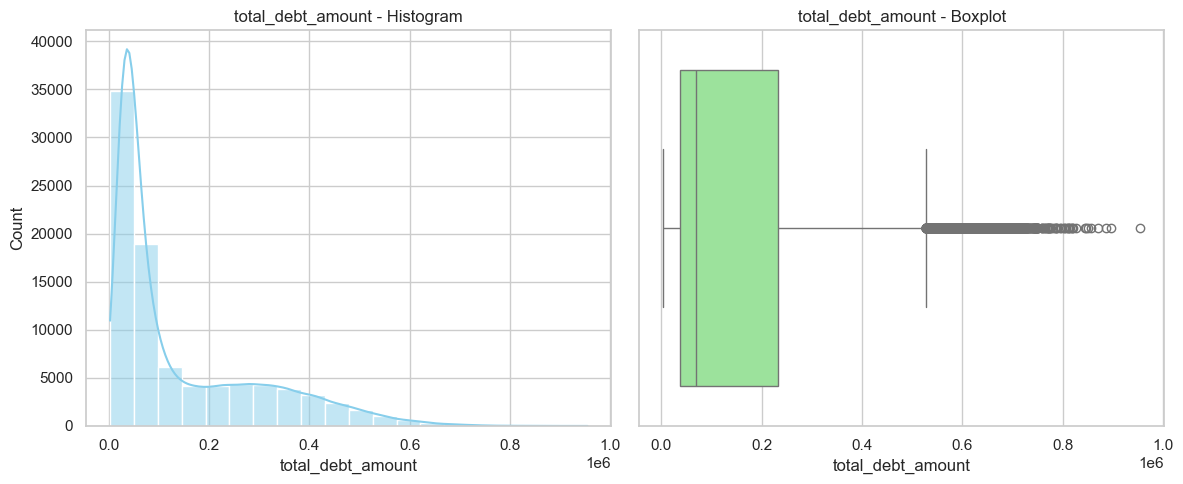

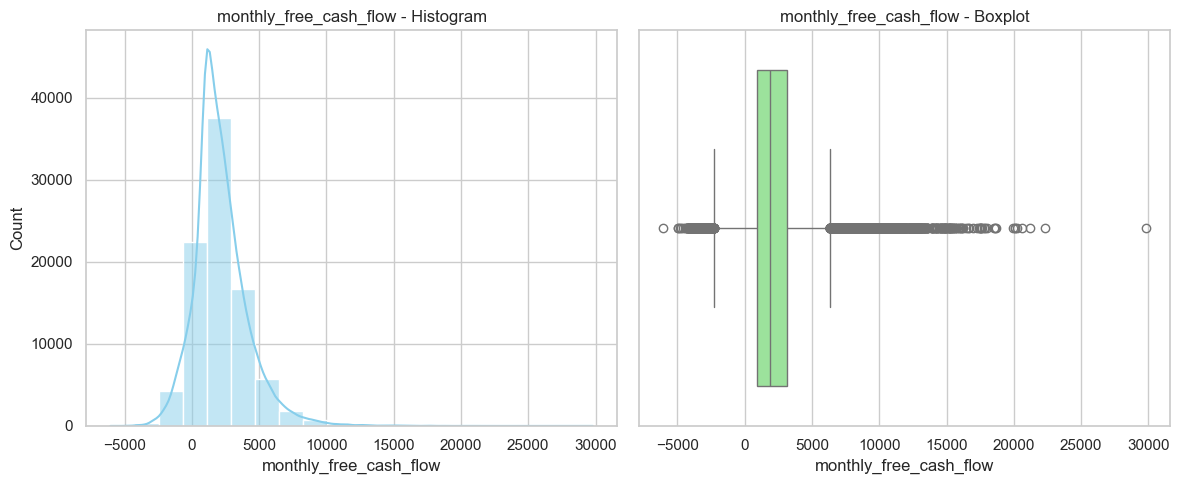

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Ma'lumotlarni yuklash
# =========================
data = pd.read_csv("financial_ratios_cleaned.csv")  # tozalangan va normalizatsiya qilinmagan fayl

# =========================
# 2. Vizualizatsiya sozlamalari
# =========================
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,5)

# =========================
# 3. Har bir ustun bo'yicha alohida grafik
# =========================
for col in data.columns:
    plt.figure(figsize=(12,5))  # har bir figure uchun alohida o'lcham
    
    if pd.api.types.is_numeric_dtype(data[col]):
        # Raqamli ustun: Histogram + Boxplot
        plt.subplot(1,2,1)
        sns.histplot(data[col], kde=True, bins=20, color='skyblue')
        plt.title(f'{col} - Histogram')
        plt.xlabel(col)
        
        plt.subplot(1,2,2)
        sns.boxplot(x=data[col], color='lightgreen')
        plt.title(f'{col} - Boxplot')
        plt.xlabel(col)
        
    else:
        # Kategorik ustun: Bar chart
        sns.countplot(x=data[col], palette='pastel', order=data[col].value_counts().index)
        plt.title(f'{col} - Bar Chart')
        plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()


In [13]:
import pandas as pd

# Oldin tozalangan data
data = pd.read_csv("financial_ratios_cleaned.csv")

# IQR asosida outlier aniqlash funksiyasi
def detect_outliers(df, cols):
    """
    Detects outliers in a list of numeric columns using IQR method.
    
    Parameters:
        df (pd.DataFrame): DataFrame to analyze
        cols (list): List of numeric columns to check
        
    Prints outlier summary for each column.
    """
    for col in cols:
        if col not in df.columns:
            print(f"Column '{col}' not found in DataFrame. Skipping...")
            continue
        
        if not pd.api.types.is_numeric_dtype(df[col]):
            print(f"Column '{col}' is not numeric. Skipping...")
            continue
        
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        
        print(f"\nColumn: {col}")
        print(f" - Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
        print(f" - Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        print(f" - Outliers count: {len(outliers)}")
        if len(outliers) > 0:
            print(f" - Outlier values (sample up to 10): {outliers.unique()[:10]}")
        else:
            print(" - No outliers detected.")

# Raqamli ustunlarni tanlash
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

# Outlierlarni aniqlash
detect_outliers(data, numeric_cols)



Column: cust_num
 - Q1: 32499.5, Q3: 77498.5, IQR: 44999.0
 - Lower Bound: -34999.0, Upper Bound: 144997.0
 - Outliers count: 0
 - No outliers detected.

Column: monthly_income
 - Q1: 2341.67, Q3: 4941.67, IQR: 2600.0
 - Lower Bound: -1558.33, Upper Bound: 8841.67
 - Outliers count: 3334
 - Outlier values (sample up to 10): [ 9425.   11016.67  9633.33 11675.   11616.67 14091.67  9008.33  9591.67
  9658.33  9983.  ]

Column: existing_monthly_debt
 - Q1: 424.475, Q3: 1168.8400000000001, IQR: 744.3650000000001
 - Lower Bound: -692.0725000000001, Upper Bound: 2285.3875000000003
 - Outliers count: 4011
 - Outlier values (sample up to 10): [2447.45 3010.02 2619.96 3272.77 3303.51 2696.53 4024.44 2595.93 2556.99
 2537.09]

Column: monthly_payment
 - Q1: 294.0, Q3: 1325.955, IQR: 1031.955
 - Lower Bound: -1253.9325, Upper Bound: 2873.8875
 - Outliers count: 4030
 - Outlier values (sample up to 10): [3295.09 3905.25 3756.59 3538.48 3178.86 3222.7  3031.77 2999.9  3917.35
 3486.65]

Column: deb

In [14]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Data yuklash
data = pd.read_csv("financial_ratios_cleaned.csv")

# 'cust_num'ni chiqarib tashlab numeric ustunlarni tanlash
numeric_cols = [col for col in data.select_dtypes(include='number').columns if col != 'cust_num']

# Min-Max scaler
scaler = MinMaxScaler()
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

# Natijani CSV ga saqlash
data.to_csv("financial_ratios_normalized.csv", index=False)

print("Data min-max normalizatsiya qilindi va 'financial_ratios_normalized.csv' faylga saqlandi.")


Data min-max normalizatsiya qilindi va 'financial_ratios_normalized.csv' faylga saqlandi.


In [21]:
import pandas as pd

# Normalizatsiyadan keyingi faylni yuklash
data = pd.read_csv("financial_ratios_normalized.csv")

# Numeric ustunlarni tanlash
numeric_cols = [col for col in data.select_dtypes(include='number').columns if col != 'cust_num']

# Har bir ustun uchun min va max qiymatni ko'rsatish
for col in numeric_cols:
    min_val = data[col].min()
    max_val = data[col].max()
    print(f"{col}: min={min_val}, max={max_val}")


monthly_income: min=0.0, max=1.0
existing_monthly_debt: min=0.0, max=1.0
monthly_payment: min=0.0, max=1.0
debt_to_income_ratio: min=0.0, max=1.0
debt_service_ratio: min=0.0, max=1.0
payment_to_income_ratio: min=0.0, max=1.0
credit_utilization: min=0.0, max=1.0
revolving_balance: min=0.0, max=1.0
credit_usage_amount: min=0.0, max=1.0
available_credit: min=0.0, max=1.0
total_monthly_debt_payment: min=0.0, max=1.0
annual_debt_payment: min=0.0, max=1.0
loan_to_annual_income: min=0.0, max=1.0
total_debt_amount: min=0.0, max=1.0
monthly_free_cash_flow: min=0.0, max=1.0


In [18]:
data = pd.read_csv("financial_ratios_normalized.csv")
data.head(10)

,cust_num,monthly_income,existing_monthly_debt,monthly_payment,debt_to_income_ratio,debt_service_ratio,payment_to_income_ratio,credit_utilization,revolving_balance,credit_usage_amount,available_credit,total_monthly_debt_payment,annual_debt_payment,loan_to_annual_income,total_debt_amount,monthly_free_cash_flow
0,10000,0.089469,0.071643,0.076668,0.044580,0.044654,0.024978,0.838906,0.320066,0.320066,0.055609,0.114039,0.114039,0.007391,0.164888,0.275355
1,10001,0.018407,0.033767,0.132691,0.117133,0.117103,0.093501,0.970618,0.170045,0.170045,0.004690,0.121080,0.121080,0.104435,0.196430,0.196070
2,10002,0.001498,0.013197,0.040226,0.054414,0.054298,0.040230,0.532928,0.048687,0.048687,0.039473,0.038406,0.038406,0.011663,0.030079,0.202371
3,10003,0.024401,0.022451,0.029162,0.031906,0.031884,0.019452,0.135765,0.018143,0.018143,0.105853,0.038532,0.038532,0.007146,0.015270,0.227209
4,10004,0.009846,0.018085,0.042484,0.050481,0.050395,0.035588,0.481256,0.053075,0.053075,0.052630,0.044175,0.044175,0.007555,0.029910,0.209716
5,10005,0.077269,0.174916,0.027100,0.077142,0.077101,0.009947,0.277609,0.038260,0.038260,0.090987,0.167472,0.167472,0.003291,0.023138,0.246161
6,10006,0.036601,0.074468,0.090131,0.091346,0.091235,0.049072,0.100304,0.012807,0.012807,0.105972,0.125932,0.125932,0.014514,0.025401,0.214383
7,10007,0.031250,0.072422,0.078387,0.090472,0.090563,0.045977,0.227964,0.037612,0.037612,0.115364,0.115916,0.115916,0.016936,0.038808,0.211559
8,10008,0.013270,0.062284,0.043440,0.087850,0.087775,0.034262,0.421479,0.018376,0.018376,0.024564,0.082647,0.082647,0.011291,0.018215,0.201957
9,10009,0.085830,0.023404,0.045831,0.016827,0.016873,0.015473,0.310030,0.037819,0.037819,0.077326,0.051079,0.051079,0.005115,0.027871,0.290188


In [16]:
missing = data.isnull().sum()

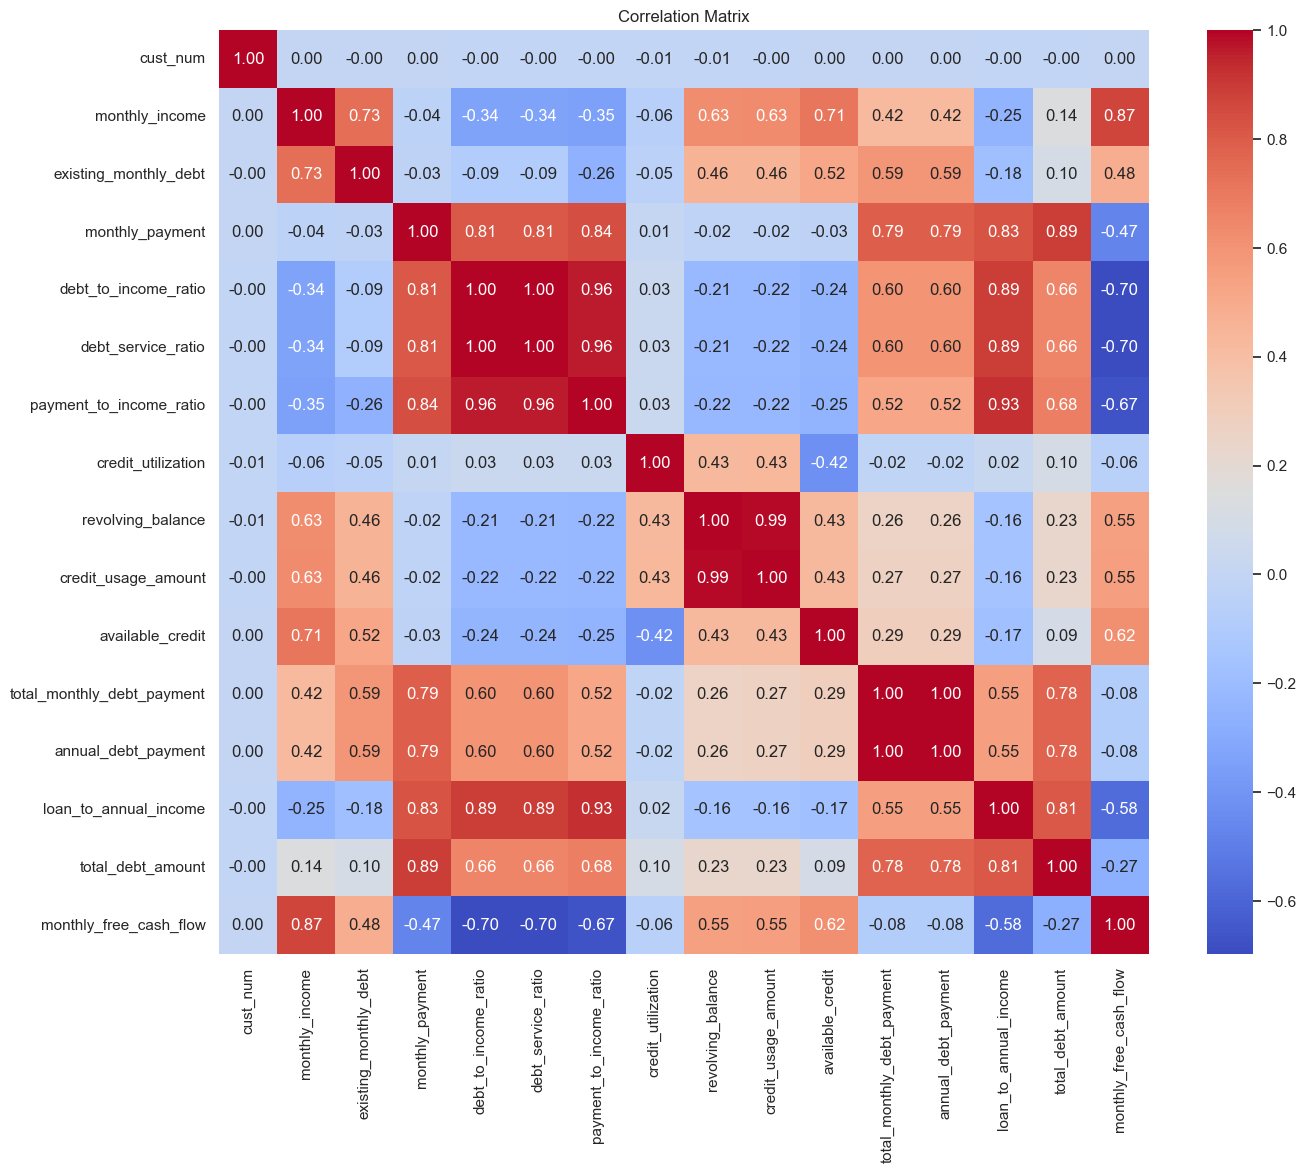

In [17]:
plt.figure(figsize=(15,12))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()
